In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 ...
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 ...
    longitude            float64 ...
    station_latitude     float64 ...
    station_longitude    float64 ...
    year                 (valid_time) int64 ...
Data variables: (12/15)
    u10                  (valid_time) float32 ...
    v10                  (valid_time) float32 ...
    d2m                  (valid_time) float32 ...
    t2m                  (valid_time) float32 ...
    msl                  (valid_time) float32 ...
    sst                  (valid_time) float32 ...
    ...                   ...
    mwp                  (valid_time) float32 ...
    swh                  (valid_time) float32 ...
    sea_level            (valid_time) float32 ...
    tide                 (vali

In [3]:
ds = xr.concat(datasets, dim="station")

In [4]:
ds

<xarray.Dataset>
Dimensions:              (station: 295, valid_time: 750192)
Coordinates:
  * station              (station) int64 1 10 102 103 104 108 ... 94 95 96 97 99
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 48.38
    longitude            float64 -4.495
    station_latitude     (station) float64 48.38 45.57 50.1 ... 49.18 49.48
    station_longitude    (station) float64 -4.495 -1.062 ... -2.117 0.1146
    year                 (valid_time) int64 1940 1940 1940 ... 2025 2025 2025
Data variables: (12/15)
    u10                  (station, valid_time) float32 -4.661 -4.882 ... 5.358
    v10                  (station, valid_time) float32 7.723 7.483 ... 1.459
    d2m                  (station, valid_time) float32 277.2 277.0 ... 289.0
    t2m                  (station, valid_time) float32 280.1 279.8 ... 290.9
    msl                  (station, valid_time) float32 1.014e+05 ... 1.02e+05
    sst                  (station, valid_time) float32 283.5 283.5 ... 292.2
    ...                   ...
    mwp                  (station, valid_time) float32 nan nan ... 3.339 3.357
    swh                  (station, valid_time) float32 nan nan ... 0.4069 0.4357
    sea_level            (station, valid_time) float32 nan nan nan ... nan nan
    tide                 (station, valid_time) float64 -1.239 -2.089 ... 0.7854
    residual             (station, valid_time) float32 nan nan nan ... nan nan
    residual_is_deviant  (station, valid_time) int8 0 0 0 0 0 0 ... 0 0 0 0 0 0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans

# --- config ---
TARGET_VAR = "residual"
N_STATIONS = 295
CSV_OUT = "gev_fit_scores.csv"
N_CLUSTERS = 3  # change if you want more/less clusters

if TARGET_VAR not in ds.data_vars:
    # fall back to "first numeric data var" if residual isn't present
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

# Helper to safely get station coordinates for labeling
def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

# Helper to get the time dimension for a single-station DataArray
def _time_dim(da):
    # assume one non-station dimension is time
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

# Goodness-of-fit helpers
def kuiper_statistic(x, cdf_func):
    """
    Kuiper statistic V = D+ + D-
    x: 1D array of samples
    cdf_func: function mapping x -> F(x)
    """
    x = np.sort(np.asarray(x))
    n = x.size
    # empirical CDF points: i/n at each x_i
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)

    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    """
    R² between empirical CDF and model CDF.
    """
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)  # slightly less extreme than i/n
    F_mod = cdf_func(x)

    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds["station"].values)[:N_STATIONS]

results = []

for s in stations:
    # DataArray for this station
    da = ds[TARGET_VAR].sel(station=s)

    # infer time dimension
    tdim = _time_dim(da)

    # drop NaNs/infs
    da = da.where(np.isfinite(da), drop=True)

    # require at least some data
    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    # bimonthly maxima (2-month block maxima)
    # requires datetime-like index on the time dimension
    try:
        da_bi = da.resample({tdim: "2M"}).max()
    except Exception as e:
        print(f"Skipping station {s}: resample failed ({e}).")
        continue

    x = da_bi.values.ravel()
    x = x[np.isfinite(x)]

    if x.size < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({x.size}).")
        continue

    # Fit GEV: params = (c, loc, scale)
    gev_params = st.genextreme.fit(x)
    c, loc, scale = gev_params

    # CDF function for this fitted GEV
    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    # K-S statistic
    ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)

    # Kuiper statistic
    kuiper = kuiper_statistic(x, gev_cdf)

    # R² between empirical CDF and model CDF
    r2 = r2_cdf_fit(x, gev_cdf)

    lat, lon = _meta_for_station(s)

    results.append(
        {
            "station": int(s),
            "lat": lat,
            "lon": lon,
            "n_blocks": int(x.size),
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
            "kuiper": kuiper,
            "r2_cdf": r2,
        }
    )

# Convert to DataFrame and save CSV
df = pd.DataFrame(results)

if df.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")

df.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

X = df[["ks_stat", "kuiper", "r2_cdf"]].values

Skipping station 110: not enough data after cleaning.
Skipping station 112: not enough data after cleaning.
Skipping station 113: not enough data after cleaning.
Skipping station 143: not enough data after cleaning.
Skipping station 145: not enough data after cleaning.
Skipping station 159: not enough data after cleaning.
Skipping station 276: not enough data after cleaning.
Skipping station 466: not enough data after cleaning.
Skipping station 472: not enough data after cleaning.
Skipping station 480: not enough data after cleaning.
Skipping station 518: not enough data after cleaning.
Skipping station 525: not enough data after cleaning.
Skipping station 557: not enough data after cleaning.
Skipping station 558: not enough data after cleaning.
Skipping station 564: not enough data after cleaning.
Skipping station 96: not enough data after cleaning.
Saved GEV fit parameters and scores to: gev_fit_scores.csv


In [21]:
df

,station,lat,lon,n_blocks,gev_c,gev_loc,gev_scale,ks_stat,ks_pvalue,kuiper,r2_cdf,cluster
0,1,48.383000,-4.495000,399,0.019139,0.396665,0.154269,0.024895,9.604563e-01,0.049499,0.998840,1
1,10,45.568480,-1.061555,237,0.008840,0.396950,0.213067,0.039537,8.380715e-01,0.076210,0.996165,1
2,102,50.102000,-5.542000,377,0.091521,0.382410,0.133945,0.028702,9.063368e-01,0.053232,0.998736,1
3,103,50.103000,-5.542750,448,0.182677,0.416630,0.338177,0.198556,5.918320e-16,0.348877,0.833575,0
4,104,50.099998,-5.533330,208,0.207246,0.355758,0.397802,0.227428,6.154688e-10,0.426214,0.779586,0
...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,49.930000,1.085000,354,0.134247,0.648707,0.249021,0.032957,8.242212e-01,0.060356,0.997792,1
275,94,49.481602,0.105600,334,-0.071086,0.606402,0.217723,0.049914,3.641023e-01,0.082405,0.994583,1
276,95,49.651299,-1.635500,307,0.041510,0.421703,0.156389,0.046830,4.964226e-01,0.092796,0.994417,1
277,97,49.183300,-2.116700,194,0.001364,0.500910,0.167137,0.047496,7.555074e-01,0.083306,0.995876,1


k=2: silhouette score=0.6618
k=3: silhouette score=0.6270
k=4: silhouette score=0.5550
k=5: silhouette score=0.5553
k=6: silhouette score=0.5436
k=7: silhouette score=0.5296
k=8: silhouette score=0.4877


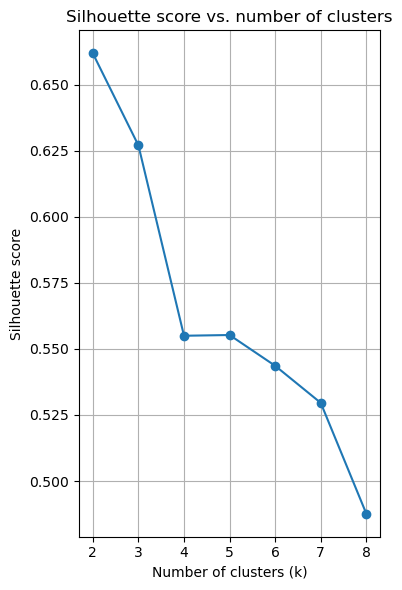

Best k by silhouette score: 2
Cluster counts with best k:
cluster
1    227
0     52
Name: count, dtype: int64


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# X = df[["ks_stat", "kuiper", "r2_cdf"]].values   # already defined above

# Range of K to test
K_RANGE = range(2, 9)  # e.g. 2 to 8 clusters

sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_k = km.fit_predict(X)
    score = silhouette_score(X, labels_k)
    sil_scores.append(score)
    print(f"k={k}: silhouette score={score:.4f}")

# Plot silhouette score vs number of clusters
plt.figure(figsize=(4, 6))
plt.plot(list(K_RANGE), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs. number of clusters")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Optional: choose best k and re-cluster ---

best_k = K_RANGE[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X)
df["cluster"] = labels

print("Cluster counts with best k:")
print(df["cluster"].value_counts())


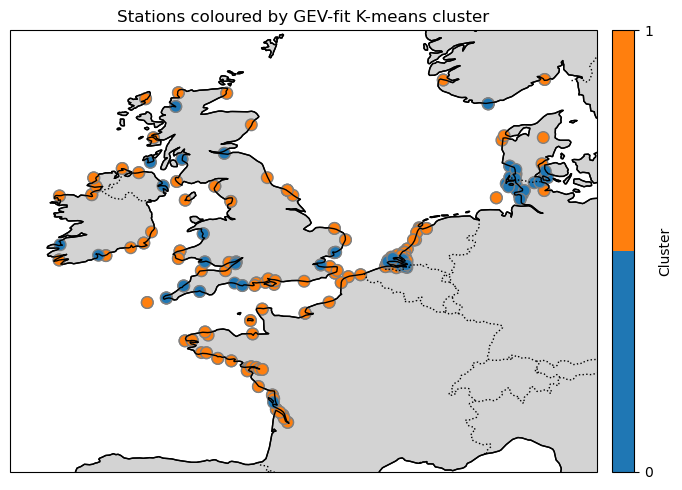

In [20]:
from matplotlib.colors import ListedColormap

def plot_cluster_map(df, cluster_col="cluster", title="Station clusters"):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes(projection=proj)

    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    pad = 2.0
    lat_min, lat_max = df["lat"].min() - pad, df["lat"].max() + pad
    lon_min, lon_max = df["lon"].min() - pad, df["lon"].max() + pad
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # Sort so that cluster 0 is plotted last (on top)
    df_sorted = df.copy()
    df_sorted["_is_zero"] = (df_sorted[cluster_col].astype(int) == 0).astype(int)
    df_sorted = df_sorted.sort_values(by="_is_zero")  # non-zero first, zero last

    clusters = df_sorted[cluster_col].astype(int).values
    unique_clusters = np.sort(np.unique(clusters))
    n_clusters = len(unique_clusters)

    # Qualitative colormap with one color per cluster
    base_cmap = plt.get_cmap("tab10")
    colors = [base_cmap(i % base_cmap.N) for i in range(n_clusters)]
    cmap = ListedColormap(colors)

    sc = ax.scatter(
        df_sorted["lon"], df_sorted["lat"],
        c=clusters,
        s=70,
        transform=proj,
        cmap=cmap,
        edgecolor="grey",
    )

    # (Station numbers removed)

    plt.title(title)
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
    cb.set_label("Cluster")

    # Integer tick labels for clusters
    cb.set_ticks(unique_clusters)
    cb.set_ticklabels([str(i) for i in unique_clusters])

    plt.tight_layout()
    plt.show()


plot_cluster_map(df_map, cluster_col="cluster", title="Stations coloured by GEV-fit K-means cluster")


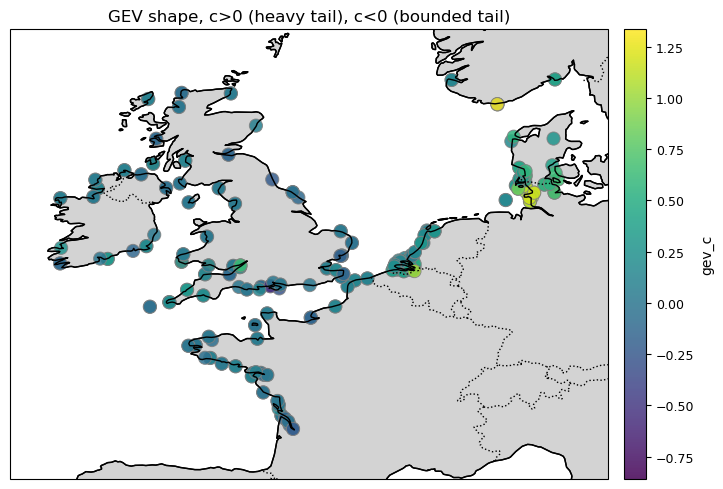

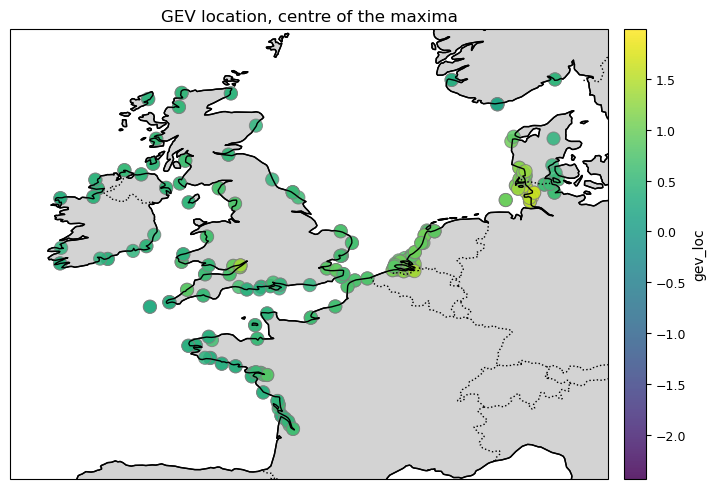

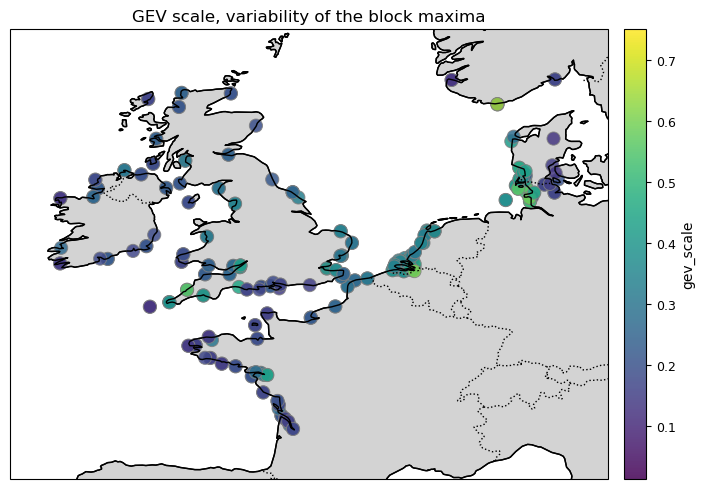

In [25]:
def plot_metric_map(df, metric_col, title, cmap="viridis"):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes(projection=proj)

    # Land + coastlines
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    # Extent with some padding
    pad = 2.0
    lat_min, lat_max = df["lat"].min() - pad, df["lat"].max() + pad
    lon_min, lon_max = df["lon"].min() - pad, df["lon"].max() + pad
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # Cleaner scatter points
    sc = ax.scatter(
        df["lon"], df["lat"],
        c=df[metric_col],
        s=90,                      # larger for visibility
        alpha=0.85,                # slight transparency
        transform=proj,
        cmap=cmap,
        edgecolor="grey",         # cleaner outlines
        linewidth=0.7
    )

    # Removed station number labels

    plt.title(title, fontsize=12)
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
    cb.set_label(metric_col, fontsize=10)

    # optional nicer tick labels
    cb.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()
	
plot_metric_map(df_map, "gev_c", "GEV shape, c>0 (heavy tail), c<0 (bounded tail)")
plot_metric_map(df_map, "gev_loc", "GEV location, centre of the maxima")
plot_metric_map(df_map, "gev_scale", "GEV scale, variability of the block maxima")

In [14]:
# Ensure cluster column exists
if "cluster" not in df.columns:
    raise RuntimeError("df['cluster'] not found — run clustering first.")

# Columns to summarize
cols_to_summarize = [
    "ks_stat",
    "kuiper",
    "r2_cdf",
    "gev_c",
    "gev_loc",
    "gev_scale",
    "n_blocks"
]

# Compute cluster means
cluster_means = df.groupby("cluster")[cols_to_summarize].mean()

print("\n=== Mean Characteristics of Each Cluster ===\n")
print(cluster_means)



=== Mean Characteristics of Each Cluster ===

          ks_stat    kuiper    r2_cdf     gev_c   gev_loc  gev_scale  \
cluster                                                                
0        0.135890  0.241051  0.936277  0.455371  0.864366   0.398112   
1        0.059358  0.106123  0.991229  0.091638  0.662079   0.258176   

           n_blocks  
cluster              
0        142.480769  
1        192.083700  


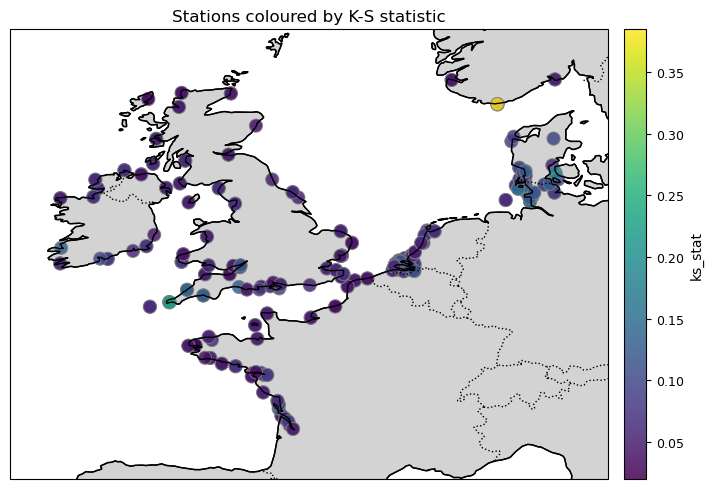

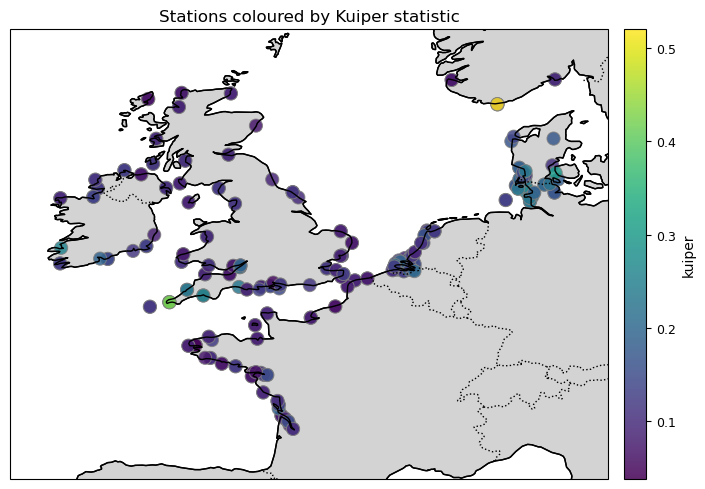

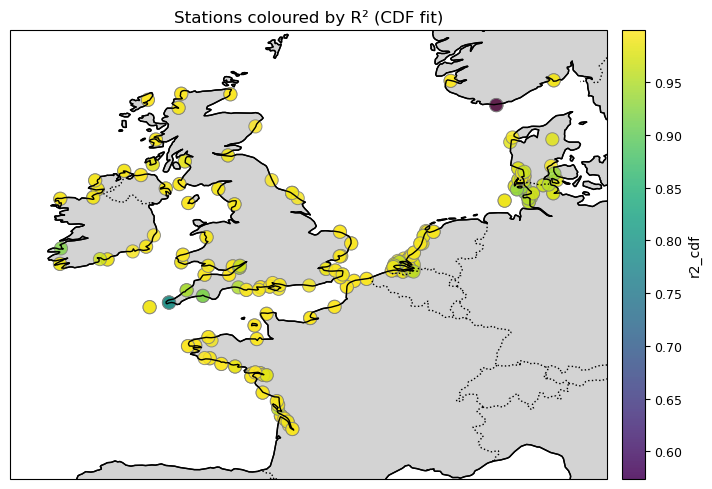

In [18]:
def plot_metric_map(df, metric_col, title, cmap="viridis"):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes(projection=proj)

    # Land + coastlines
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    # Extent with some padding
    pad = 2.0
    lat_min, lat_max = df["lat"].min() - pad, df["lat"].max() + pad
    lon_min, lon_max = df["lon"].min() - pad, df["lon"].max() + pad
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # Cleaner scatter points
    sc = ax.scatter(
        df["lon"], df["lat"],
        c=df[metric_col],
        s=90,                      # larger for visibility
        alpha=0.85,                # slight transparency
        transform=proj,
        cmap=cmap,
        edgecolor="grey",         # cleaner outlines
        linewidth=0.7
    )

    # Removed station number labels

    plt.title(title, fontsize=12)
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
    cb.set_label(metric_col, fontsize=10)

    # optional nicer tick labels
    cb.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()


plot_metric_map(df_map, "ks_stat", "Stations coloured by K-S statistic")
plot_metric_map(df_map, "kuiper", "Stations coloured by Kuiper statistic")
plot_metric_map(df_map, "r2_cdf", "Stations coloured by R² (CDF fit)")

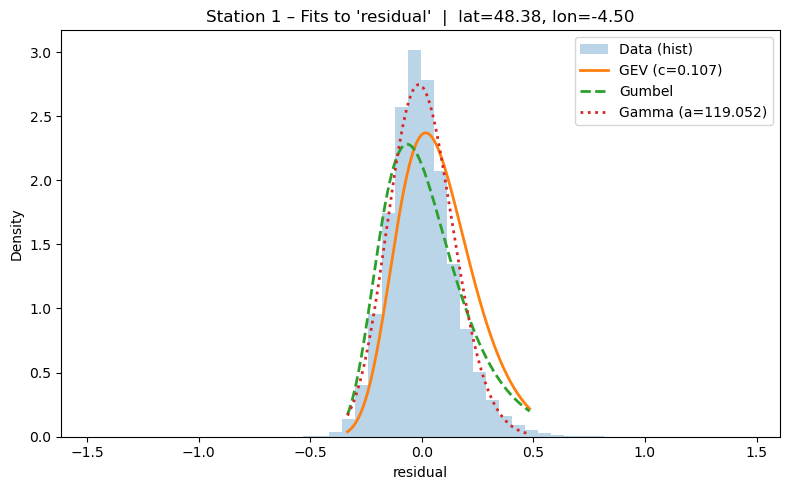

Station 1 params:
  GEV:    c=0.107014, loc=0.000002, scale=0.156171
  Gumbel: loc=-0.065599, scale=0.161274
  Gamma:  a=119.052304, loc=-1.590615, scale=0.013362
------------------------------------------------------------


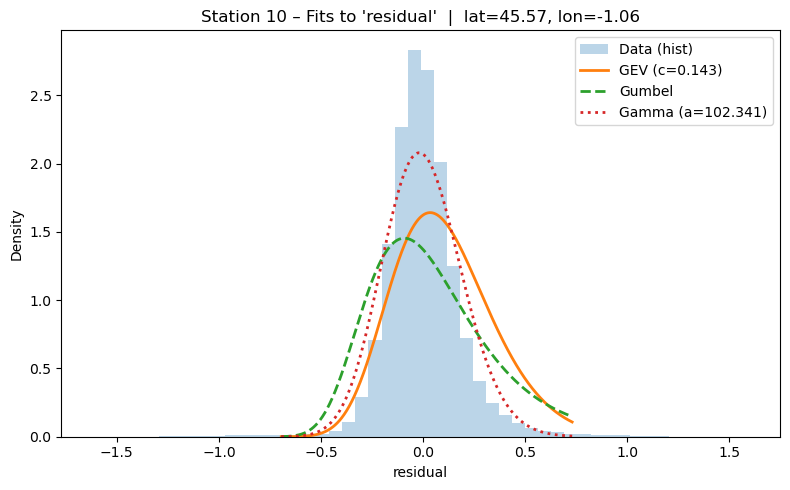

Station 10 params:
  GEV:    c=0.142653, loc=-0.000000, scale=0.226554
  Gumbel: loc=-0.092181, scale=0.253035
  Gamma:  a=102.340535, loc=-1.948857, scale=0.019042
------------------------------------------------------------


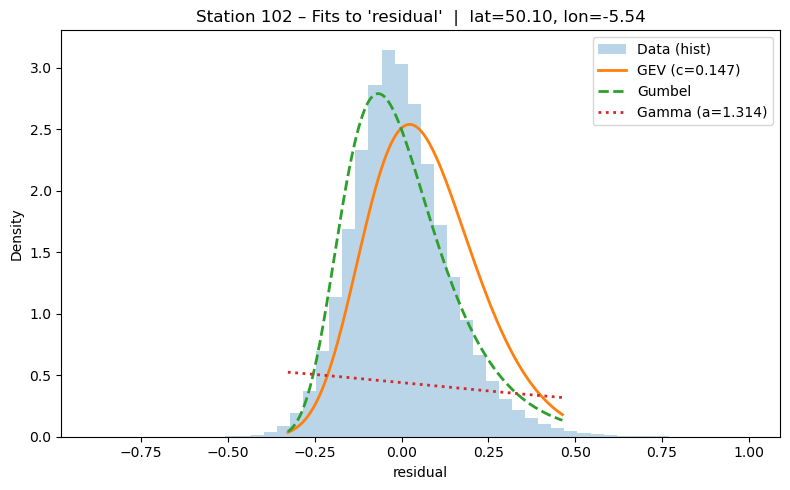

Station 102 params:
  GEV:    c=0.147194, loc=-0.000000, scale=0.146585
  Gumbel: loc=-0.067642, scale=0.131920
  Gamma:  a=1.314487, loc=-0.885467, scale=1.019520
------------------------------------------------------------


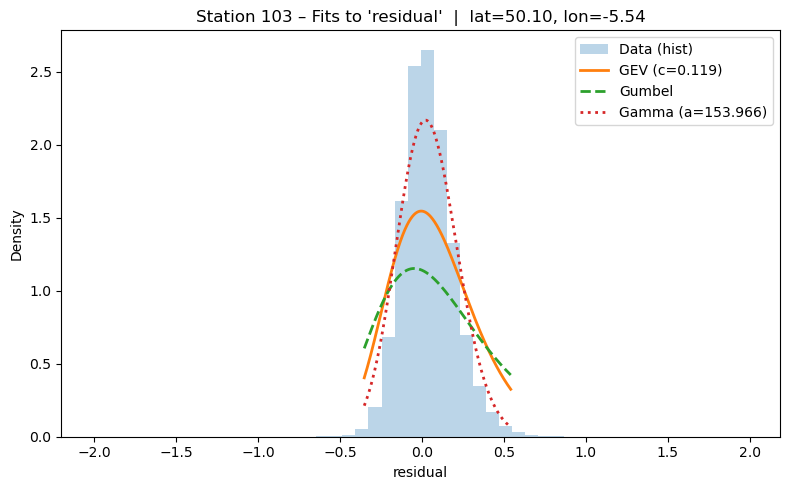

Station 103 params:
  GEV:    c=0.118721, loc=-0.034014, scale=0.239768
  Gumbel: loc=-0.046484, scale=0.319205
  Gamma:  a=153.965889, loc=-2.251743, scale=0.014865
------------------------------------------------------------


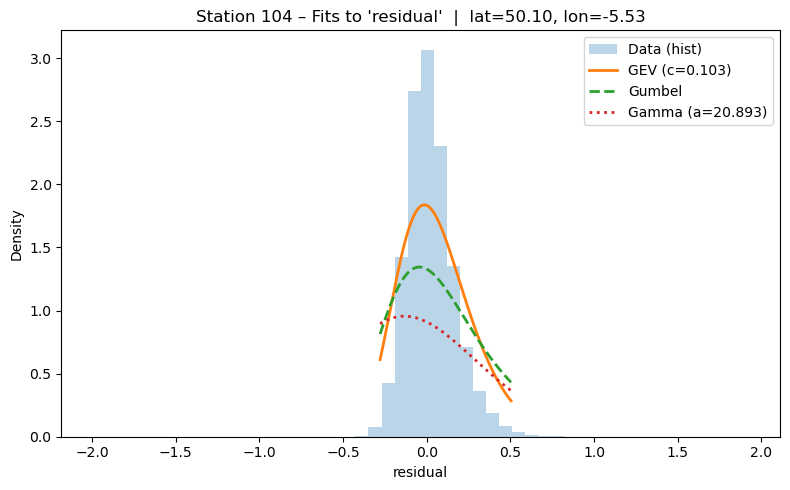

Station 104 params:
  GEV:    c=0.103102, loc=-0.036090, scale=0.201270
  Gumbel: loc=-0.043490, scale=0.273507
  Gamma:  a=20.893041, loc=-1.987915, scale=0.093227
------------------------------------------------------------


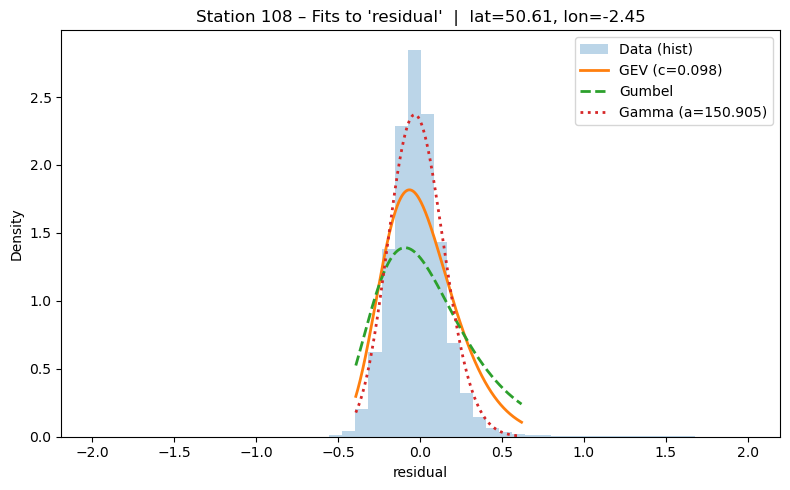

Station 108 params:
  GEV:    c=0.097558, loc=-0.085545, scale=0.203487
  Gumbel: loc=-0.091731, scale=0.264461
  Gamma:  a=150.904643, loc=-2.091787, scale=0.013738
------------------------------------------------------------


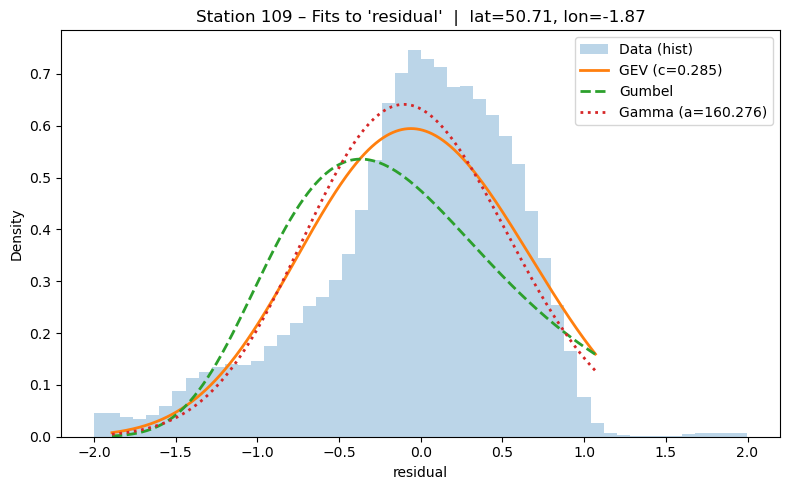

Station 109 params:
  GEV:    c=0.284732, loc=-0.267391, scale=0.647328
  Gumbel: loc=-0.367847, scale=0.686875
  Gamma:  a=160.275598, loc=-7.951947, scale=0.049276
------------------------------------------------------------


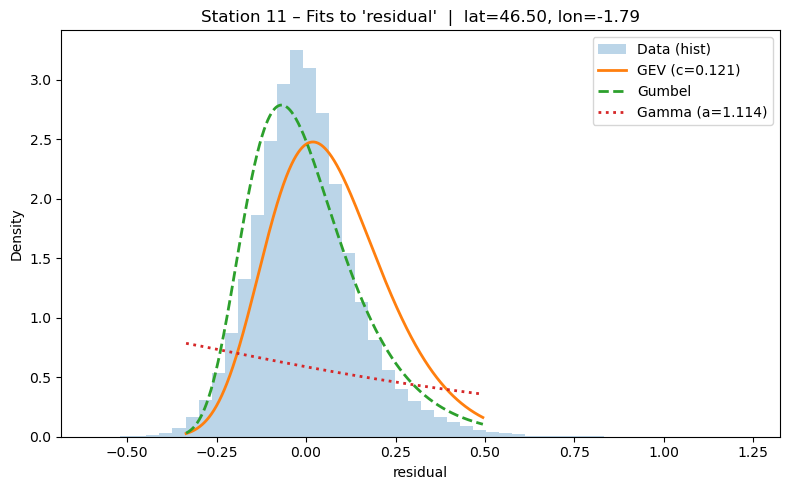

Station 11 params:
  GEV:    c=0.121231, loc=-0.000000, scale=0.149614
  Gumbel: loc=-0.068625, scale=0.131953
  Gamma:  a=1.114087, loc=-0.592371, scale=0.872482
------------------------------------------------------------
Skipping station 110: not enough data after cleaning.


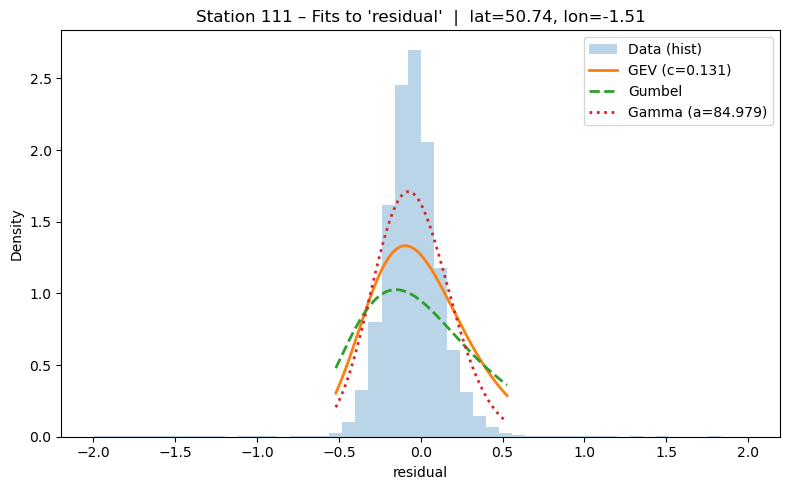

Station 111 params:
  GEV:    c=0.130748, loc=-0.132957, scale=0.278572
  Gumbel: loc=-0.151630, scale=0.358555
  Gamma:  a=84.979284, loc=-2.210964, scale=0.025441
------------------------------------------------------------


In [ ]:
# Fit GEV, Gumbel, and Gamma to the first 10 stations and plot curves
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

# --- config ---
TARGET_VAR = "residual"
N_STATIONS = 10
HIST_BINS = 50


if TARGET_VAR not in ds.data_vars:
    # fall back to "first numeric data var" if sst isn't present
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

# Helper to safely get station coordinates for labeling
def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

stations = np.array(ds["station"].values)[:N_STATIONS]

for s in stations:
    # extract the 1D time series for this station
    # shape: (valid_time,)
    arr = ds[TARGET_VAR].sel(station=s).values
    arr = np.asarray(arr).ravel()

    # drop NaNs and infs
    x = arr[np.isfinite(arr)]
    if x.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    # If you need block maxima for extremes, you could transform x here (e.g., yearly maxima).
    # For now we fit to the full sample:
    #   GEV (genextreme), Gumbel (gumbel_r), Gamma (gamma)
    # MLE fits
    gev_params = st.genextreme.fit(x)        # (c, loc, scale)
    gum_params = st.gumbel_r.fit(x)          # (loc, scale)
    gam_params = st.gamma.fit(x)             # (a, loc, scale)

    # x-grid for smooth PDFs: use interior percentiles to avoid crazy tails
    x_min, x_max = np.percentile(x, [0.5, 99.5])
    xs = np.linspace(x_min, x_max, 800)

    # PDFs
    gev_pdf = st.genextreme.pdf(xs, *gev_params)
    gum_pdf = st.gumbel_r.pdf(xs, *gum_params)
    gam_pdf = st.gamma.pdf(xs, *gam_params)

    # Plot: one figure per station (no subplots)
    plt.figure(figsize=(8, 5))
    # histogram normalized to pdf
    plt.hist(x, bins=HIST_BINS, density=True, alpha=0.3, label="Data (hist)")

    # overlay PDFs
    plt.plot(xs, gev_pdf, linewidth=2, label=f"GEV (c={gev_params[0]:.3f})")
    plt.plot(xs, gum_pdf, linewidth=2, linestyle="--", label="Gumbel")
    plt.plot(xs, gam_pdf, linewidth=2, linestyle=":", label=f"Gamma (a={gam_params[0]:.3f})")

    # labels and title
    lat, lon = _meta_for_station(s)
    meta = f"  |  lat={lat:.2f}, lon={lon:.2f}" if (lat is not None and lon is not None) else ""
    plt.title(f"Station {int(s)} – Fits to '{TARGET_VAR}'{meta}")
    plt.xlabel(TARGET_VAR)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # (Optional) print parameters neatly
    print(f"Station {int(s)} params:")
    print(f"  GEV:    c={gev_params[0]:.6f}, loc={gev_params[1]:.6f}, scale={gev_params[2]:.6f}")
    print(f"  Gumbel: loc={gum_params[0]:.6f}, scale={gum_params[1]:.6f}")
    print(f"  Gamma:  a={gam_params[0]:.6f}, loc={gam_params[1]:.6f}, scale={gam_params[2]:.6f}")
    print("-" * 60)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

# ---- config ----
TARGET_VAR = "residual"
MIN_YEARS = 20                  # minimum annual maxima per station
CSV_OUT   = "gev_yearlymax_by_station.csv"

rows = []
for s in np.array(ds["station"].values):
    # yearly maxima (keep times to identify the year of the max)
    da = ds[TARGET_VAR].sel(station=s)
    yearly_max_da = da.resample(valid_time="Y").max(skipna=True)
    x_all = yearly_max_da.values
    t_all = yearly_max_da["valid_time"].values

    # clean finite
    mask = np.isfinite(x_all)
    x = x_all[mask]
    t = t_all[mask]
    n = x.size

    # defaults
    annual_max_val = np.nan
    annual_max_year = np.nan

    if n >= 1:
        imax = int(np.nanargmax(x))
        annual_max_val = float(x[imax])
        # extract calendar year from the timestamp
        annual_max_year = int(pd.to_datetime(t[imax]).year)

    if n < MIN_YEARS:
        rows.append({
            "station": int(s), "n_years": n,
            "annual_max": annual_max_val,
            "annual_max_year": annual_max_year,
            "c": np.nan, "loc": np.nan, "scale": np.nan,
            "ks_D": np.nan, "ks_p": np.nan,
            "lat": float(ds["station_latitude"].sel(station=s).values),
            "lon": float(ds["station_longitude"].sel(station=s).values),
            "status": f"skipped (<{MIN_YEARS} years)"
        })
        continue

    # fit GEV
    try:
        c_shape, loc, scale = st.genextreme.fit(x)  # (c, loc, scale)
        D_gev, p_gev = st.kstest(x, 'genextreme', args=(c_shape, loc, scale))
        status = "ok"
    except Exception as e:
        c_shape = loc = scale = D_gev = p_gev = np.nan
        status = f"fit_error: {e}"

    # station metadata
    lat = float(ds["station_latitude"].sel(station=s).values)
    lon = float(ds["station_longitude"].sel(station=s).values)

    rows.append({
        "station": int(s),
        "n_years": n,
        "annual_max": annual_max_val,
        "annual_max_year": annual_max_year,
        "c": c_shape,
        "loc": loc,
        "scale": scale,
        "ks_D": D_gev,
        "ks_p": p_gev,
        "lat": lat,
        "lon": lon,
        "status": status
    })

# save to CSV
df = pd.DataFrame(rows)
df.to_csv(CSV_OUT, index=False)
print(f"Saved: {CSV_OUT}")
display(df.head())


Saved: gev_yearlymax_by_station.csv


,station,n_years,annual_max,annual_max_year,c,loc,scale,ks_D,ks_p,lat,lon,status
0,1,67,1.458786,1987.0,-0.066898,0.686735,0.126416,0.059355,0.961121,48.383000,-4.495000,ok
1,10,45,1.587813,1963.0,0.226203,0.729844,0.278690,0.117021,0.530366,45.568480,-1.061555,ok
2,102,64,0.995433,1989.0,0.130419,0.603166,0.115003,0.042656,0.999507,50.102000,-5.542000,ok
3,103,75,1.985308,2019.0,-0.228568,0.671869,0.148922,0.104798,0.357385,50.103000,-5.542750,ok
4,104,35,1.915684,2019.0,-0.440297,0.612946,0.135504,0.124137,0.609374,50.099998,-5.533330,ok


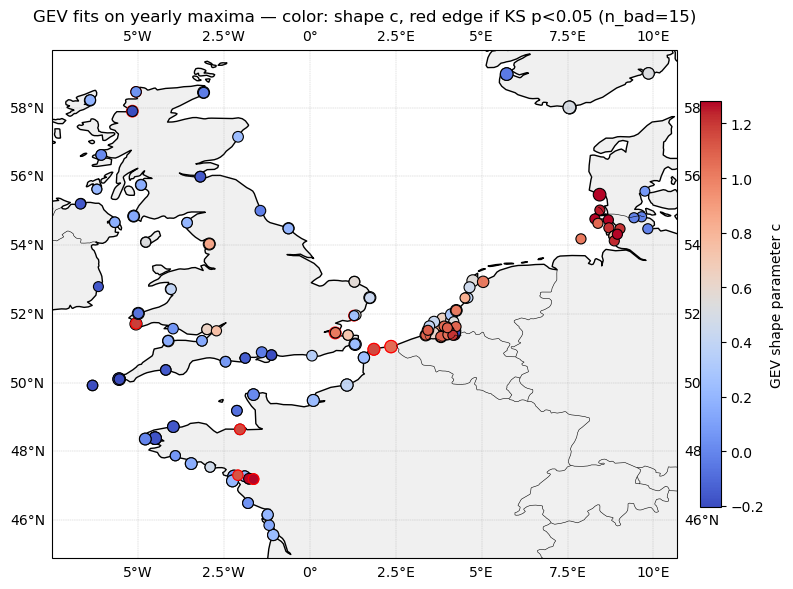

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# subset to successful fits
df_ok = df[(df["status"] == "ok") & np.isfinite(df["c"])].copy()
if df_ok.empty:
    print("No stations with successful fits; check MIN_YEARS or data.")
else:
    # simple robust clipping for color scale (avoid a few crazy outliers)
    c_lo, c_hi = np.nanpercentile(df_ok["c"], [5, 95])
    c_lo, c_hi = float(c_lo), float(c_hi)
    # marker sizes
    size = 50 + 0.6*(df_ok["n_years"] - df_ok["n_years"].min())

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f0f0f0")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), zorder=0)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4)
    ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

    sc = ax.scatter(
        df_ok["lon"], df_ok["lat"], c=df_ok["c"], s=size,
        cmap="coolwarm", vmin=c_lo, vmax=c_hi,
        edgecolors=np.where(df_ok["ks_p"] < 0.05, "red", "black"),
        linewidths=0.8, transform=ccrs.PlateCarree(), alpha=1,
        label="Stations"
    )
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.8, pad=0.02)
    cb.set_label("GEV shape parameter c")

    n_bad = int((df_ok["ks_p"] < 0.05).sum())
    plt.title(f"GEV fits on yearly maxima — color: shape c, red edge if KS p<0.05 (n_bad={n_bad})")

    plt.tight_layout()
    plt.show()


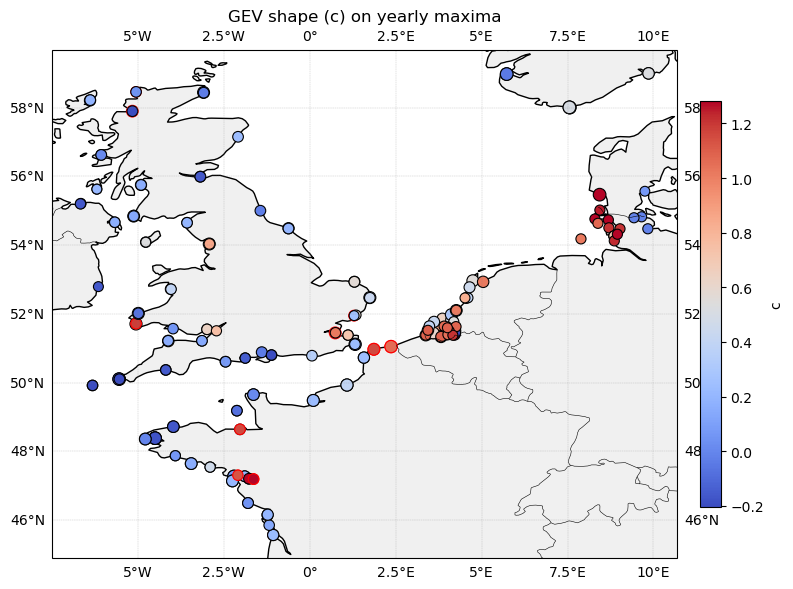

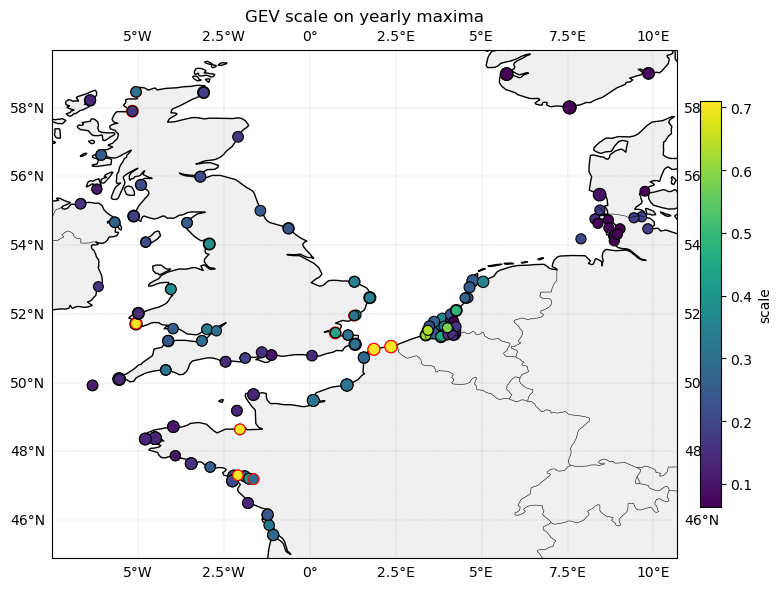

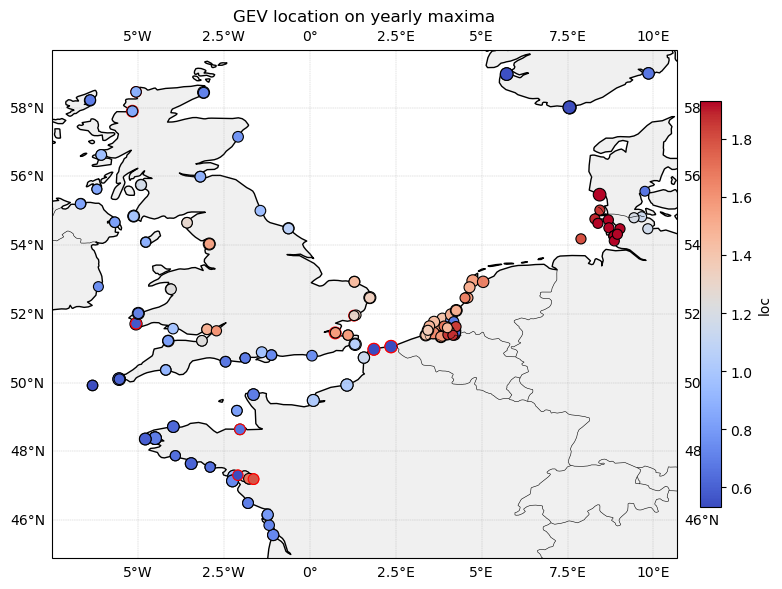

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def _robust_limits(series, lo=5, hi=95, floor_zero=False):
    if floor_zero:
        series = series.clip(lower=0)
    vmin, vmax = np.nanpercentile(series, [lo, hi])
    if vmin == vmax:
        vmin = float(series.min())
        vmax = float(series.max())
    return float(vmin), float(vmax)

def plot_param_map(df_ok, param, title, cmap="coolwarm", edge_bad=True, floor_zero=False):
    vals = df_ok[param].astype(float)
    vmin, vmax = _robust_limits(vals, floor_zero=floor_zero)

    size = 50 + 0.6*(df_ok["n_years"] - df_ok["n_years"].min())

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f0f0f0")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), zorder=0)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4)
    ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

    edgecols = np.where(df_ok["ks_p"] < 0.05, "red", "black") if edge_bad else "black"

    sc = ax.scatter(
        df_ok["lon"], df_ok["lat"], c=vals, s=size,
        cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolors=edgecols, linewidths=0.8,
        transform=ccrs.PlateCarree(), alpha=1
    )
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.8, pad=0.02)
    cb.set_label(param)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# 1) Shape parameter c (can be +/- → diverging colormap)
plot_param_map(df_ok,
               param="c",
               title="GEV shape (c) on yearly maxima",
               cmap="coolwarm",
               edge_bad=True,
               floor_zero=False)

# 2) Scale parameter (always >=0 → sequential colormap → floor_zero=True)
plot_param_map(df_ok,
               param="scale",
               title="GEV scale on yearly maxima",
               cmap="viridis",
               edge_bad=True,
               floor_zero=True)

# 3) Location parameter (can be +/- → diverging colormap)
plot_param_map(df_ok,
               param="loc",
               title="GEV location on yearly maxima",
               cmap="coolwarm",
               edge_bad=True,
               floor_zero=False)


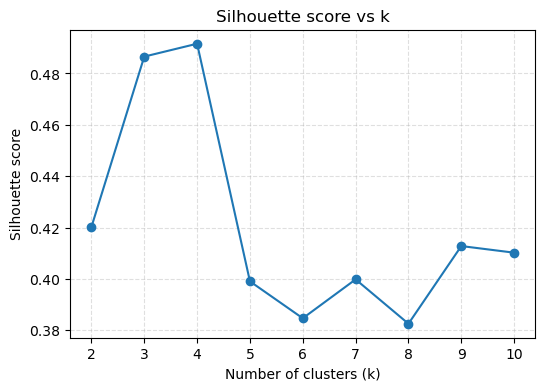

Best k by silhouette score: k = 4, score = 0.492


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Work only with usable stations
df_ok = df[(df["status"] == "ok") & np.isfinite(df["c"]) & np.isfinite(df["annual_max"])].copy()

features = ["c", "loc", "scale", "annual_max"]
df_cluster = df_ok.dropna(subset=features).copy()

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[features])

sil_scores = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(ks, sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs k")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

best_k = ks[np.argmax(sil_scores)]
print(f"Best k by silhouette score: k = {best_k}, score = {max(sil_scores):.3f}")


In [ ]:
k = best_k
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
df_cluster["cluster"] = kmeans.fit_predict(X)


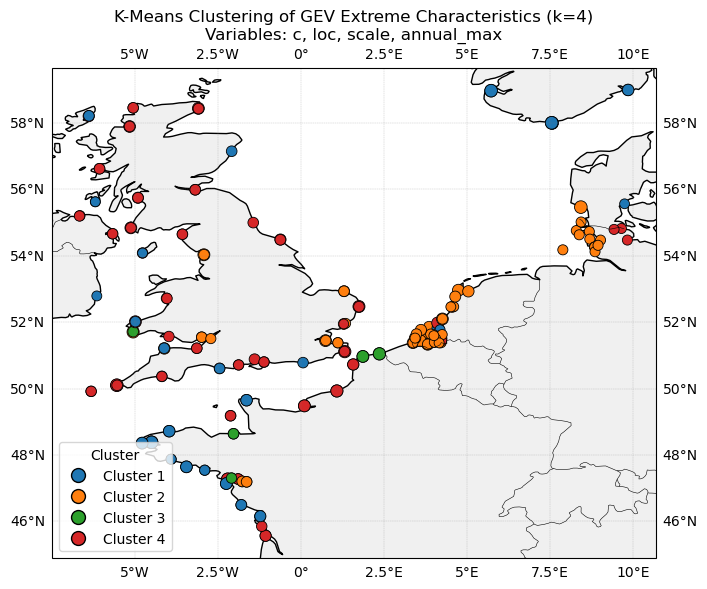

In [ ]:
import matplotlib.colors as mcolors

# Define a discrete colormap with exactly k colors
cluster_colors = plt.cm.tab10(np.arange(k))
cmap = mcolors.ListedColormap(cluster_colors[:k])
norm = mcolors.BoundaryNorm(np.arange(-0.5, k+0.5, 1), cmap.N)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f0f0f0")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

sizes = 50 + 0.6*(df_cluster["n_years"] - df_cluster["n_years"].min())

sc = ax.scatter(
    df_cluster["lon"], df_cluster["lat"],
    c=df_cluster["cluster"], s=sizes,
    cmap=cmap, norm=norm,
    edgecolors="black", linewidths=0.6,
    transform=ccrs.PlateCarree()
)

# ---- DISCRETE LEGEND instead of colorbar ----
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='white',
           label=f"Cluster {i+1}", markerfacecolor=cluster_colors[i], markersize=10, markeredgecolor='black')
    for i in range(k)
]
ax.legend(handles=legend_elements, title="Cluster", loc="lower left")

plt.title(f"K-Means Clustering of GEV Extreme Characteristics (k={k})\n"
          "Variables: c, loc, scale, annual_max")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

# Baseline GEV parameters (SciPy's parameterization): (c, loc, scale)
c0, loc0, scale0 = 0.0, 0.0, 1.0   # c=0 ≈ Gumbel

# x-range wide enough to see differences
xs = np.linspace(-4, 6, 1000)

# ---- 1) Vary SHAPE c (tail heaviness / boundedness) ----
c_vals = [-0.2, 0.0, 0.2]   # c<0: bounded upper tail; c=0: Gumbel; c>0: heavy tail
plt.figure(figsize=(12,4))
ax = plt.subplot(1,3,1)
for c in c_vals:
    pdf = st.genextreme.pdf(xs, c, loc=loc0, scale=scale0)
    ax.plot(xs, pdf, label=f"c={c:+.1f}")
ax.set_title("Effect of shape c")
ax.set_xlabel("x"); ax.set_ylabel("PDF")
ax.legend(title="shape")

# ---- 2) Vary SCALE (spreads distribution) ----
scale_vals = [0.6, 1.0, 1.6]
ax = plt.subplot(1,3,2)
for sc in scale_vals:
    pdf = st.genextreme.pdf(xs, c0, loc=loc0, scale=sc)
    ax.plot(xs, pdf, label=f"scale={sc:.1f}")
ax.set_title("Effect of scale")
ax.set_xlabel("x"); ax.set_ylabel("PDF")
ax.legend(title="scale")

# ---- 3) Vary LOCATION (shifts distribution left/right) ----
loc_vals = [-1.0, 0.0, +1.0]
ax = plt.subplot(1,3,3)
for lo in loc_vals:
    pdf = st.genextreme.pdf(xs, c0, loc=lo, scale=scale0)
    ax.plot(xs, pdf, label=f"loc={lo:+.1f}")
    ax.axvline(lo, ls=":", lw=1, alpha=0.4)  # show shift reference
ax.set_title("Effect of location")
ax.set_xlabel("x"); ax.set_ylabel("PDF")
ax.legend(title="loc")

plt.tight_layout()
plt.show()


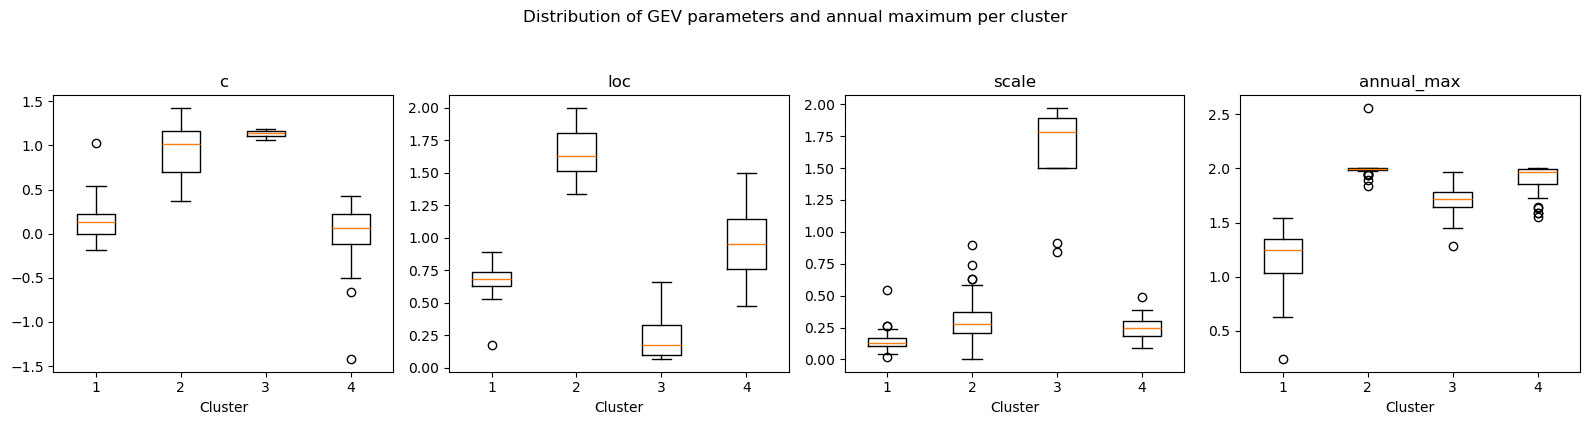

In [ ]:
# Ensure df_cluster is available (with column "cluster")
group_stats = df_cluster.groupby("cluster")[["c", "loc", "scale", "annual_max"]].agg(
    ["mean", "median", "std", "min", "max"]
)


params = ["c", "loc", "scale", "annual_max"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=False)
for ax, param in zip(axes, params):
    ax.boxplot([df_cluster.loc[df_cluster["cluster"] == k, param] for k in range(k)],
               labels=[f"{i+1}" for i in range(k)], showfliers=True)
    ax.set_title(param)
    ax.set_xlabel("Cluster")
plt.suptitle("Distribution of GEV parameters and annual maximum per cluster", y=1.05)
plt.tight_layout()
plt.show()


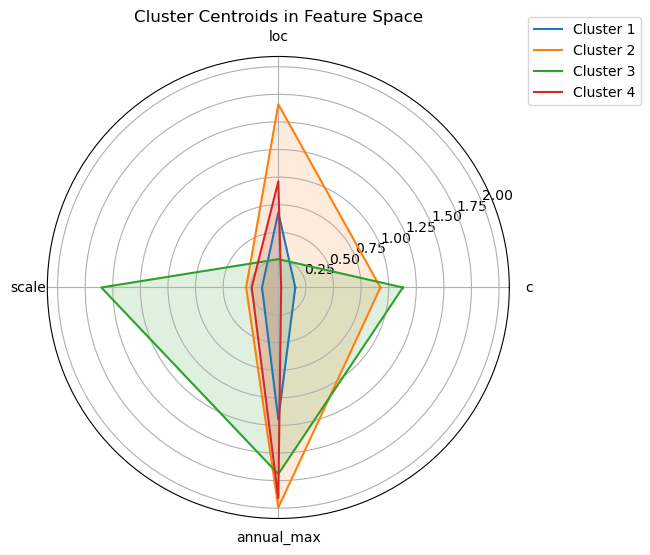

In [ ]:
import numpy as np

features = ["c", "loc", "scale", "annual_max"]
centroids = df_cluster.groupby("cluster")[features].mean()

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # loop back

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for cl in centroids.index:
    vals = centroids.loc[cl].values
    vals = np.concatenate((vals, [vals[0]]))
    ax.plot(angles, vals, label=f"Cluster {cl+1}")
    ax.fill(angles, vals, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_title("Cluster Centroids in Feature Space")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()


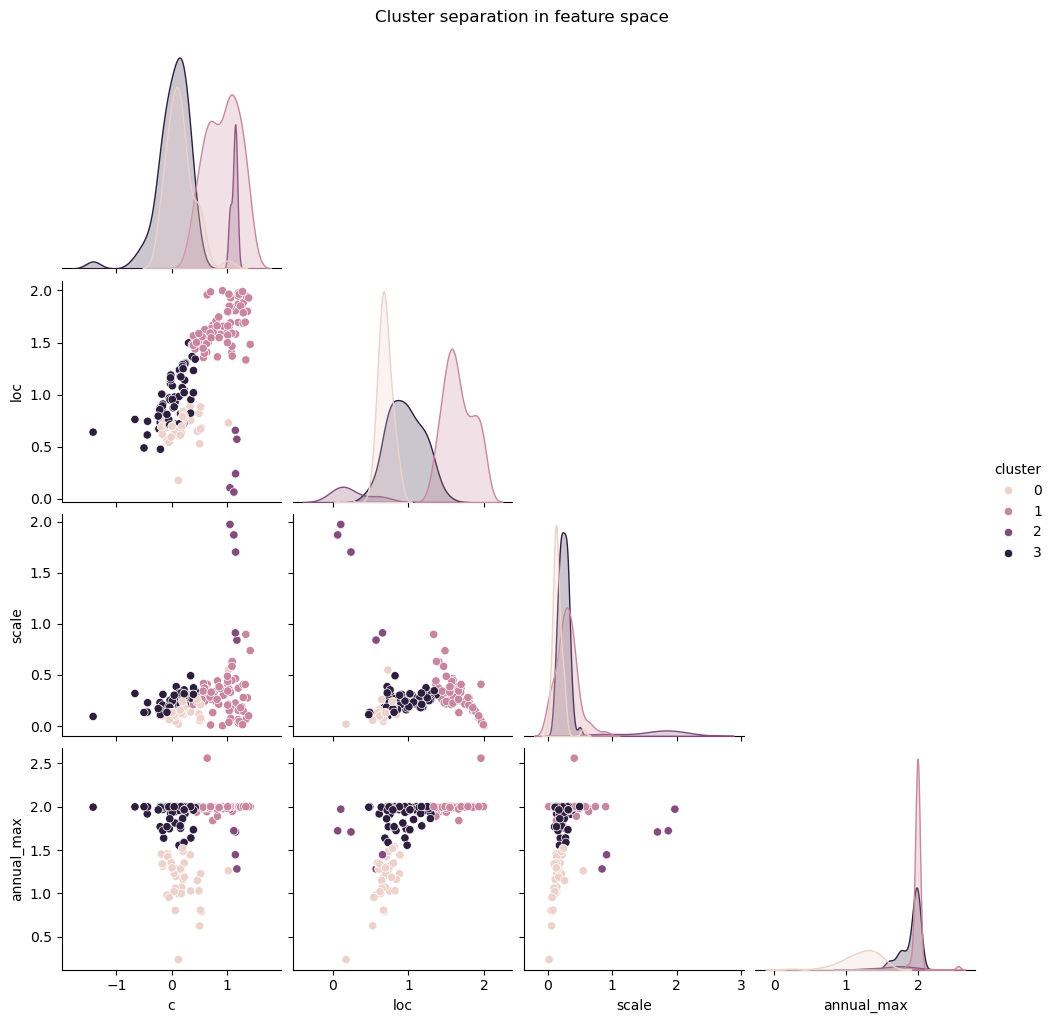

In [ ]:
import seaborn as sns

sns.pairplot(df_cluster, vars=["c","loc","scale","annual_max"],
             hue="cluster", diag_kind="kde", corner=True)
plt.suptitle("Cluster separation in feature space", y=1.02)
plt.show()


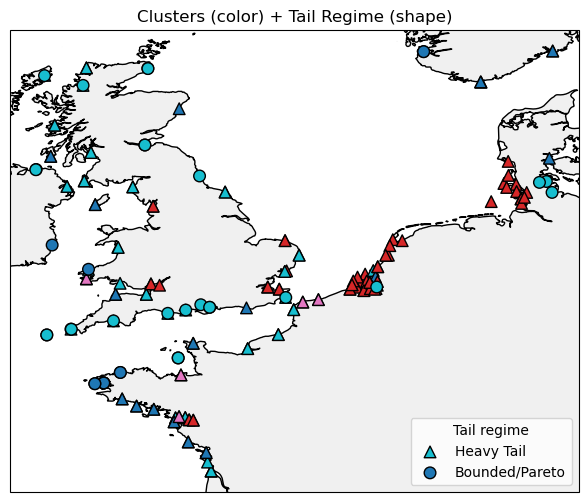

: 

In [ ]:
df_cluster["tail_index"] = np.where(df_cluster["c"] > 0, "Heavy Tail", "Bounded/Pareto")

shape_map = {"Heavy Tail":"^", "Bounded/Pareto":"o"}

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
ax.add_feature(cfeature.COASTLINE, zorder =0)

for shape_cat in shape_map:
    subset = df_cluster[df_cluster["tail_index"] == shape_cat]
    ax.scatter(subset["lon"], subset["lat"],
               c=subset["cluster"], cmap="tab10",
               marker=shape_map[shape_cat], edgecolors="black",
               s=70, transform=ccrs.PlateCarree(),
               label=shape_cat)

ax.legend(title="Tail regime")
plt.title("Clusters (color) + Tail Regime (shape)")
plt.show()


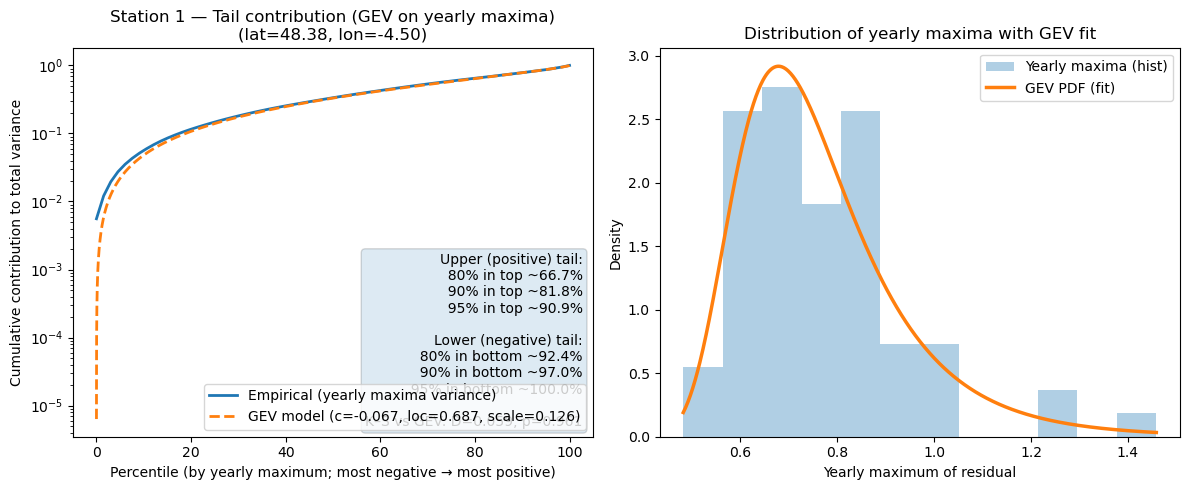

Station 1 — GEV on yearly maxima:
  params: c=-0.066898, loc=0.686735, scale=0.126416
  KS D=0.0594, p=0.9611


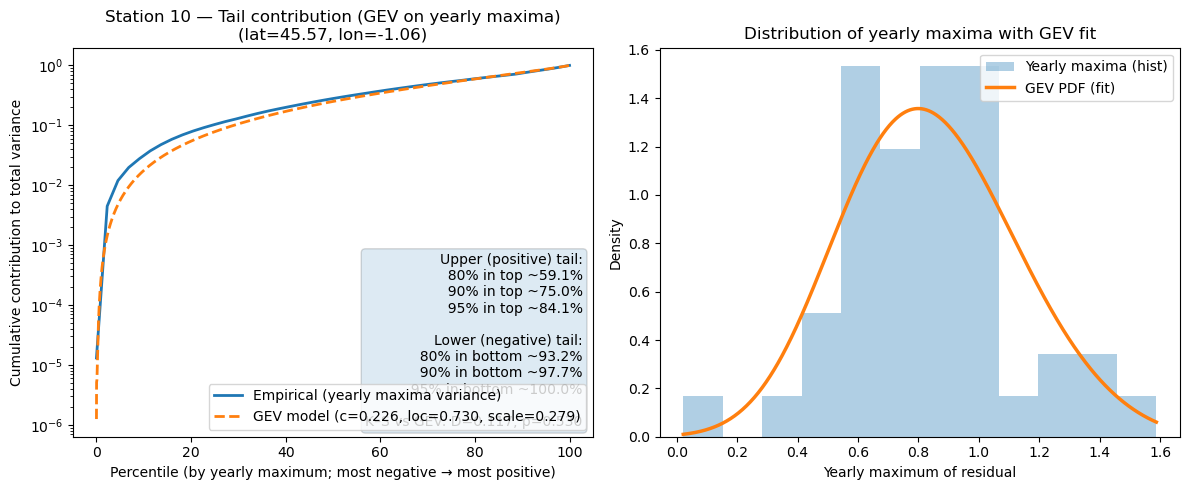

Station 10 — GEV on yearly maxima:
  params: c=0.226203, loc=0.729844, scale=0.278690
  KS D=0.1170, p=0.5304


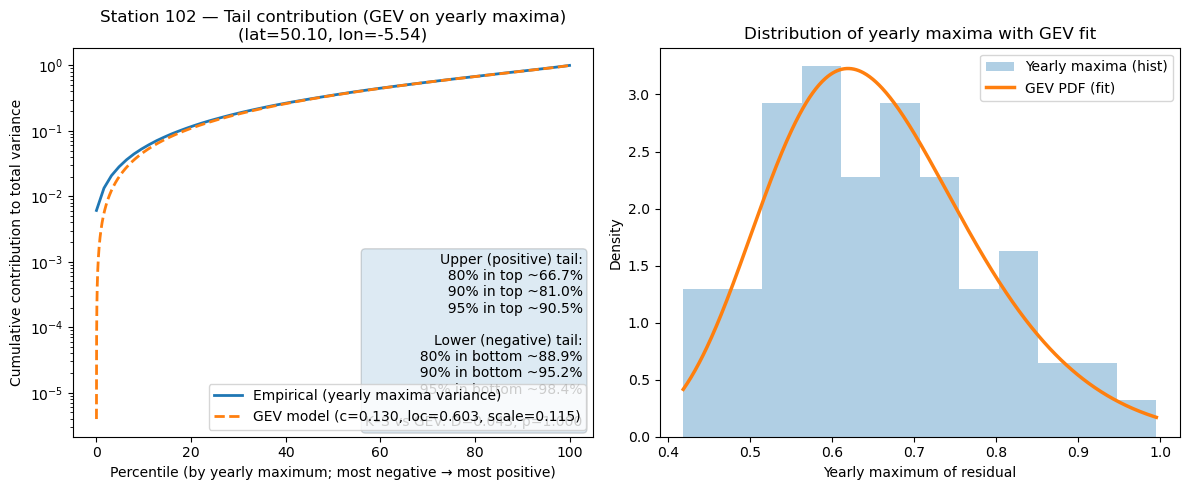

Station 102 — GEV on yearly maxima:
  params: c=0.130419, loc=0.603166, scale=0.115003
  KS D=0.0427, p=0.9995


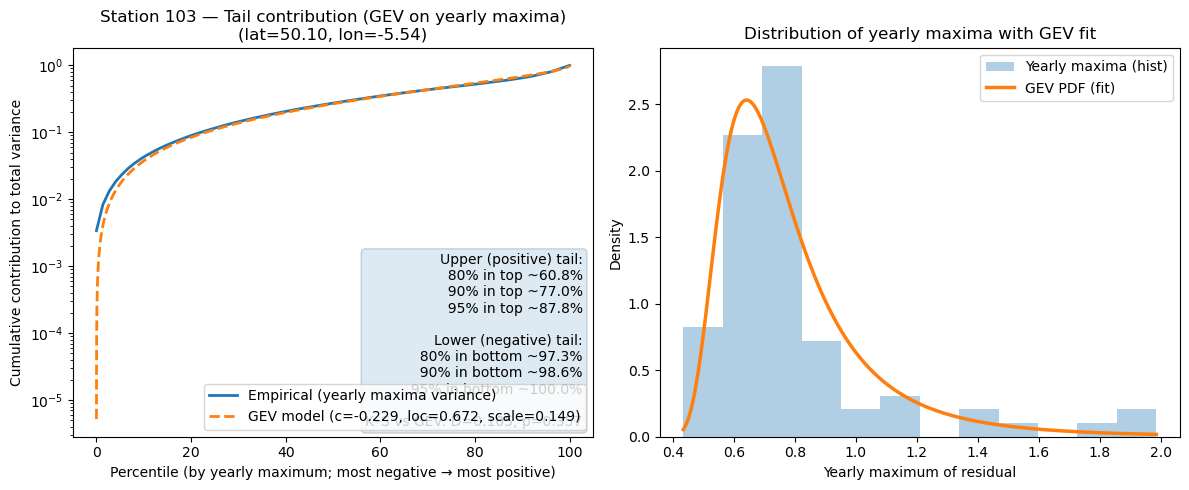

Station 103 — GEV on yearly maxima:
  params: c=-0.228568, loc=0.671869, scale=0.148922
  KS D=0.1048, p=0.3574
Skipping station 104: only 35 yearly maxima (need ≥ 40).
Skipping station 108: only 34 yearly maxima (need ≥ 40).
Skipping station 109: only 29 yearly maxima (need ≥ 40).
Skipping station 11: only 38 yearly maxima (need ≥ 40).
Skipping station 110: only 0 yearly maxima (need ≥ 40).
Skipping station 111: only 18 yearly maxima (need ≥ 40).
Skipping station 112: only 0 yearly maxima (need ≥ 40).
Skipping station 113: only 0 yearly maxima (need ≥ 40).
Skipping station 114: only 12 yearly maxima (need ≥ 40).
Skipping station 115: only 13 yearly maxima (need ≥ 40).
Skipping station 12: only 36 yearly maxima (need ≥ 40).


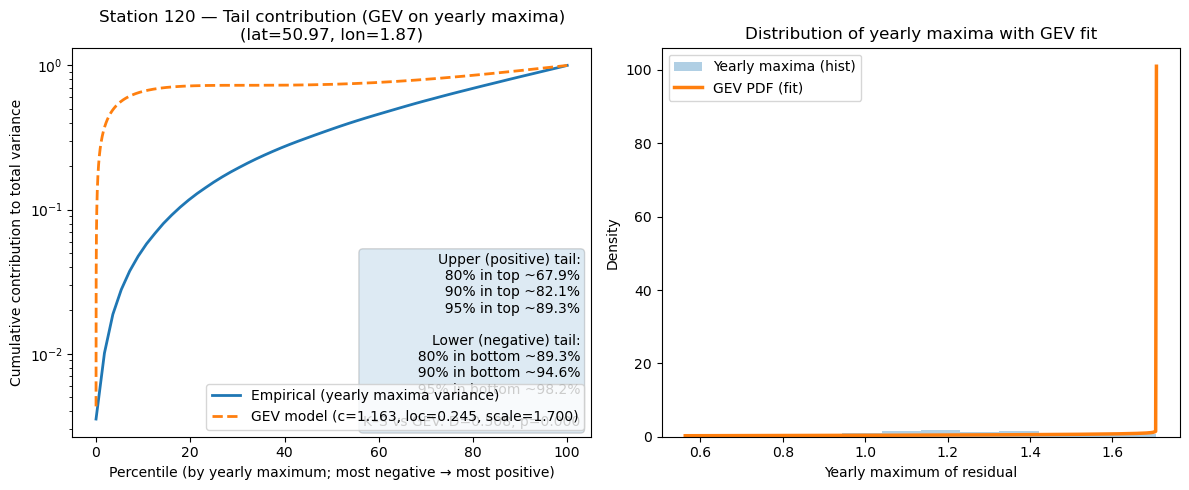

Station 120 — GEV on yearly maxima:
  params: c=1.162886, loc=0.244972, scale=1.699917
  KS D=0.5079, p=0.0000


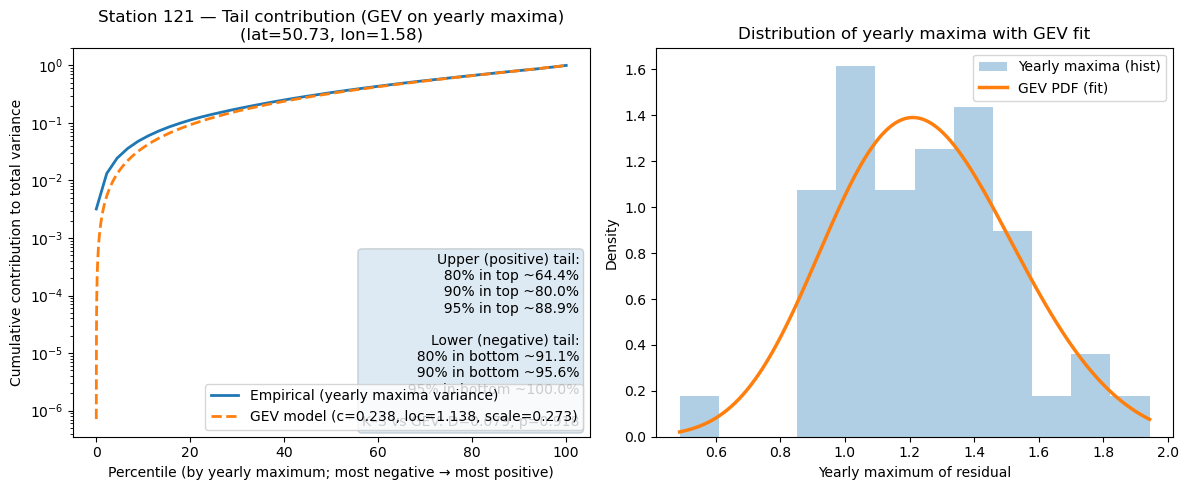

Station 121 — GEV on yearly maxima:
  params: c=0.237794, loc=1.138343, scale=0.272805
  KS D=0.0785, p=0.9180


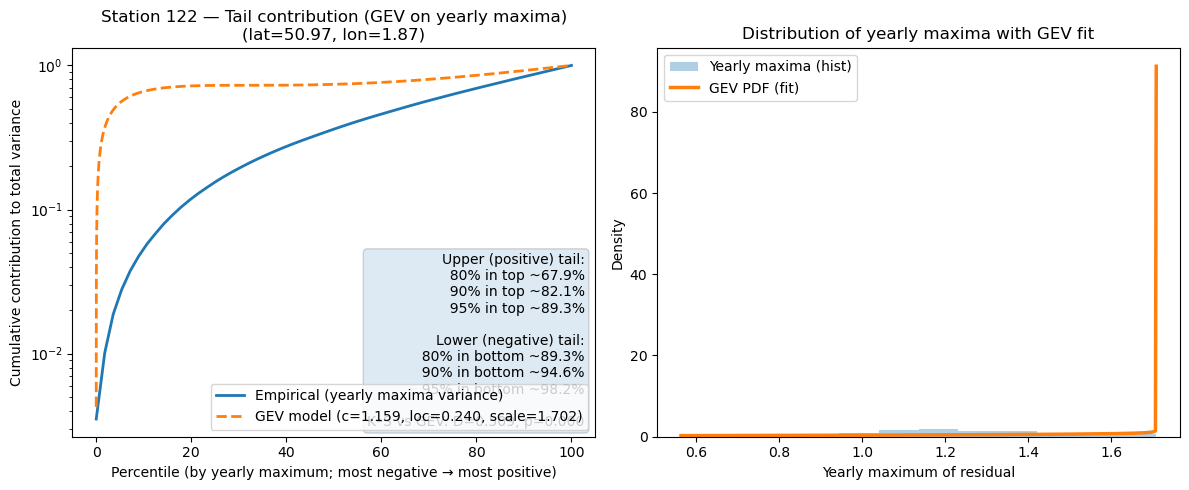

Station 122 — GEV on yearly maxima:
  params: c=1.159185, loc=0.240079, scale=1.701777
  KS D=0.5091, p=0.0000


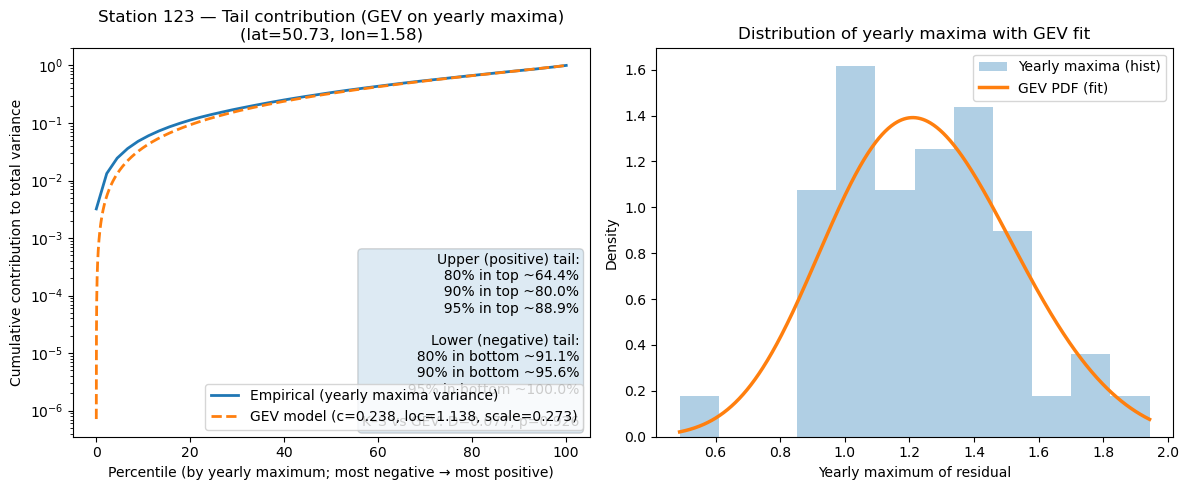

Station 123 — GEV on yearly maxima:
  params: c=0.237878, loc=1.138443, scale=0.272772
  KS D=0.0774, p=0.9256
Skipping station 124: only 34 yearly maxima (need ≥ 40).
Skipping station 125: only 34 yearly maxima (need ≥ 40).
Skipping station 126: only 34 yearly maxima (need ≥ 40).
Skipping station 127: only 34 yearly maxima (need ≥ 40).
Skipping station 128: only 28 yearly maxima (need ≥ 40).
Skipping station 129: only 19 yearly maxima (need ≥ 40).
Skipping station 13: only 36 yearly maxima (need ≥ 40).
Skipping station 130: only 18 yearly maxima (need ≥ 40).
Skipping station 131: only 17 yearly maxima (need ≥ 40).
Skipping station 133: only 15 yearly maxima (need ≥ 40).
Skipping station 14: only 35 yearly maxima (need ≥ 40).
Skipping station 140: only 39 yearly maxima (need ≥ 40).
Skipping station 141: only 30 yearly maxima (need ≥ 40).
Skipping station 142: only 29 yearly maxima (need ≥ 40).
Skipping station 143: only 0 yearly maxima (need ≥ 40).
Skipping station 145: only 0 yearly m

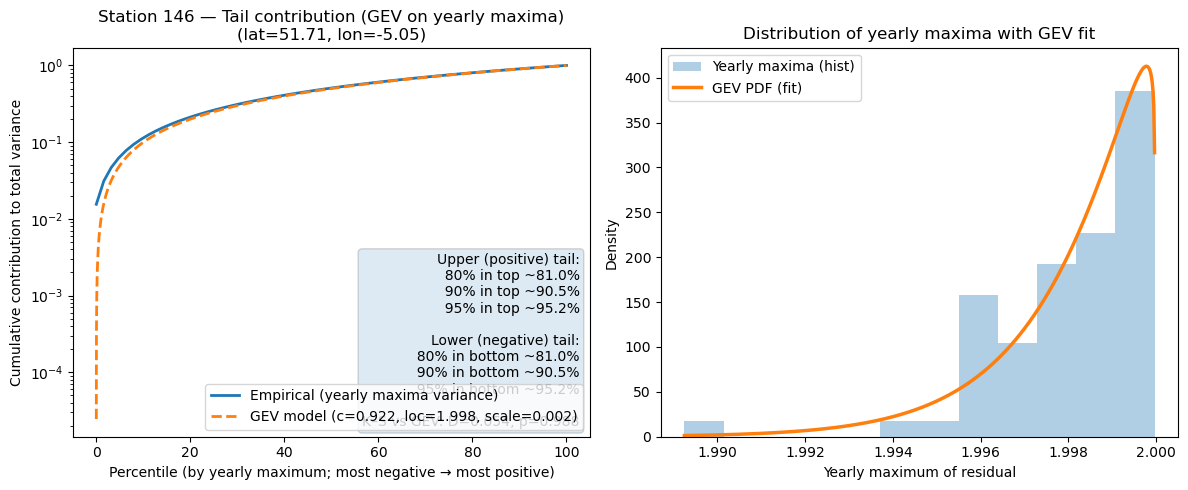

Station 146 — GEV on yearly maxima:
  params: c=0.922158, loc=1.997977, scale=0.001837
  KS D=0.0537, p=0.9878
Skipping station 147: only 19 yearly maxima (need ≥ 40).
Skipping station 148: only 15 yearly maxima (need ≥ 40).
Skipping station 15: only 34 yearly maxima (need ≥ 40).
Skipping station 151: only 35 yearly maxima (need ≥ 40).
Skipping station 152: only 19 yearly maxima (need ≥ 40).
Skipping station 153: only 15 yearly maxima (need ≥ 40).
Skipping station 154: only 14 yearly maxima (need ≥ 40).


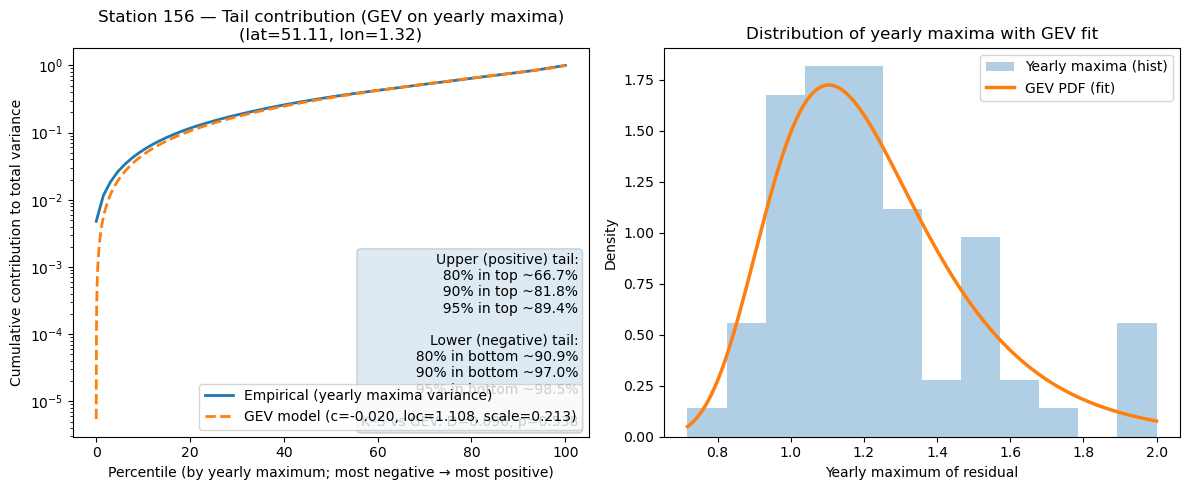

Station 156 — GEV on yearly maxima:
  params: c=-0.020125, loc=1.108129, scale=0.213417
  KS D=0.0958, p=0.5378


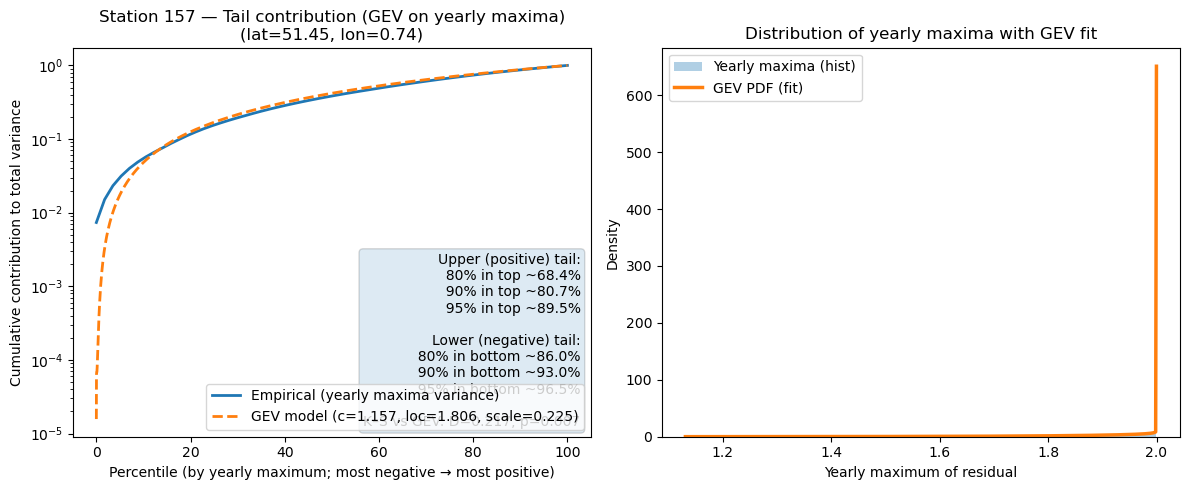

Station 157 — GEV on yearly maxima:
  params: c=1.157026, loc=1.805523, scale=0.224839
  KS D=0.2167, p=0.0072


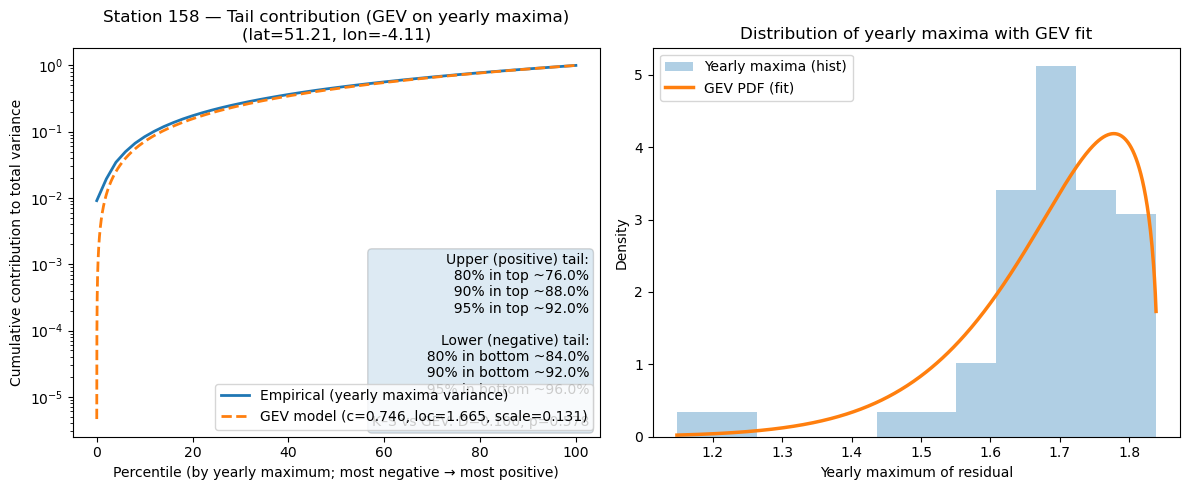

Station 158 — GEV on yearly maxima:
  params: c=0.745919, loc=1.665259, scale=0.130817
  KS D=0.1060, p=0.5783
Skipping station 159: only 0 yearly maxima (need ≥ 40).
Skipping station 16: only 26 yearly maxima (need ≥ 40).
Skipping station 160: only 38 yearly maxima (need ≥ 40).
Skipping station 161: only 32 yearly maxima (need ≥ 40).
Skipping station 162: only 32 yearly maxima (need ≥ 40).
Skipping station 163: only 15 yearly maxima (need ≥ 40).
Skipping station 164: only 8 yearly maxima (need ≥ 40).
Skipping station 165: only 17 yearly maxima (need ≥ 40).
Skipping station 166: only 29 yearly maxima (need ≥ 40).
Skipping station 167: only 19 yearly maxima (need ≥ 40).
Skipping station 168: only 13 yearly maxima (need ≥ 40).
Skipping station 17: only 30 yearly maxima (need ≥ 40).


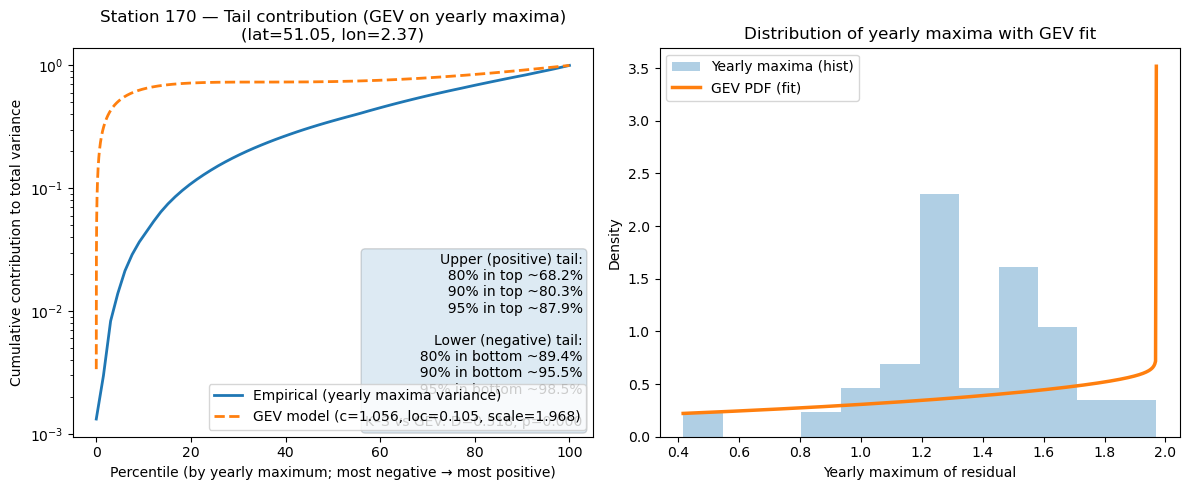

Station 170 — GEV on yearly maxima:
  params: c=1.055590, loc=0.105487, scale=1.968238
  KS D=0.5180, p=0.0000


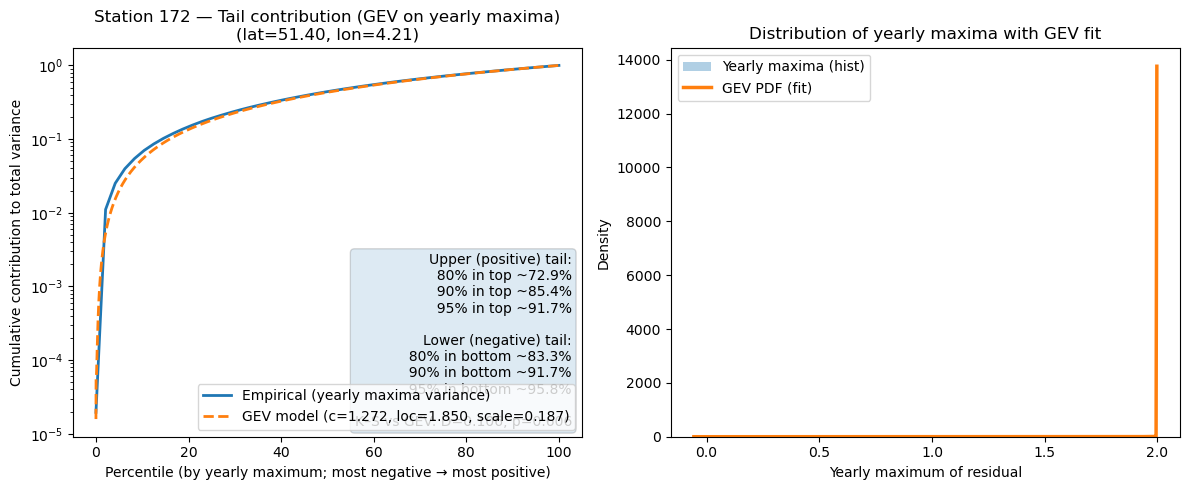

Station 172 — GEV on yearly maxima:
  params: c=1.271946, loc=1.850045, scale=0.187336
  KS D=0.1058, p=0.6056
Skipping station 173: only 22 yearly maxima (need ≥ 40).
Skipping station 174: only 30 yearly maxima (need ≥ 40).
Skipping station 175: only 15 yearly maxima (need ≥ 40).


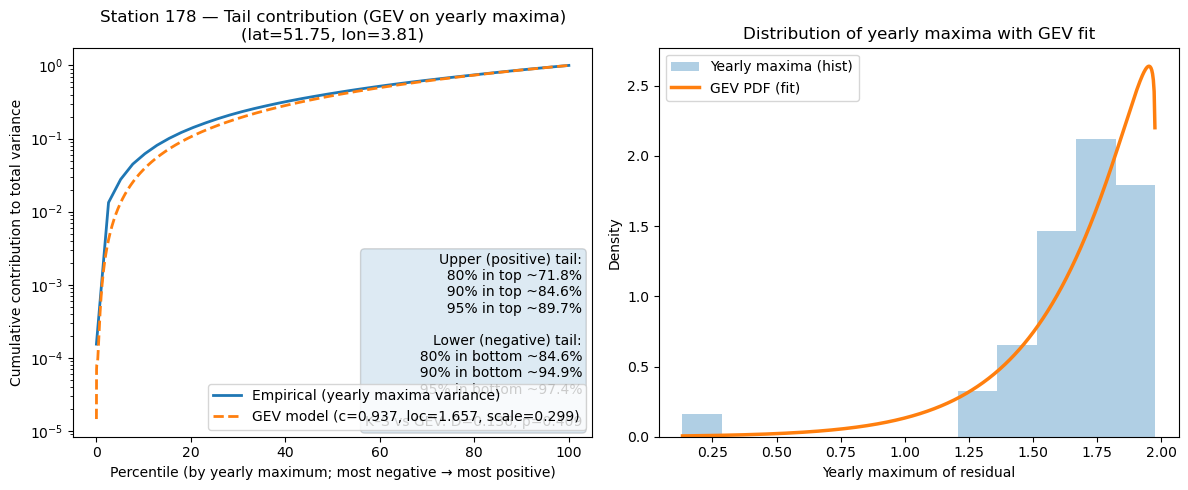

Station 178 — GEV on yearly maxima:
  params: c=0.937195, loc=1.656735, scale=0.299092
  KS D=0.1364, p=0.4095
Skipping station 179: only 26 yearly maxima (need ≥ 40).
Skipping station 18: only 27 yearly maxima (need ≥ 40).
Skipping station 180: only 18 yearly maxima (need ≥ 40).


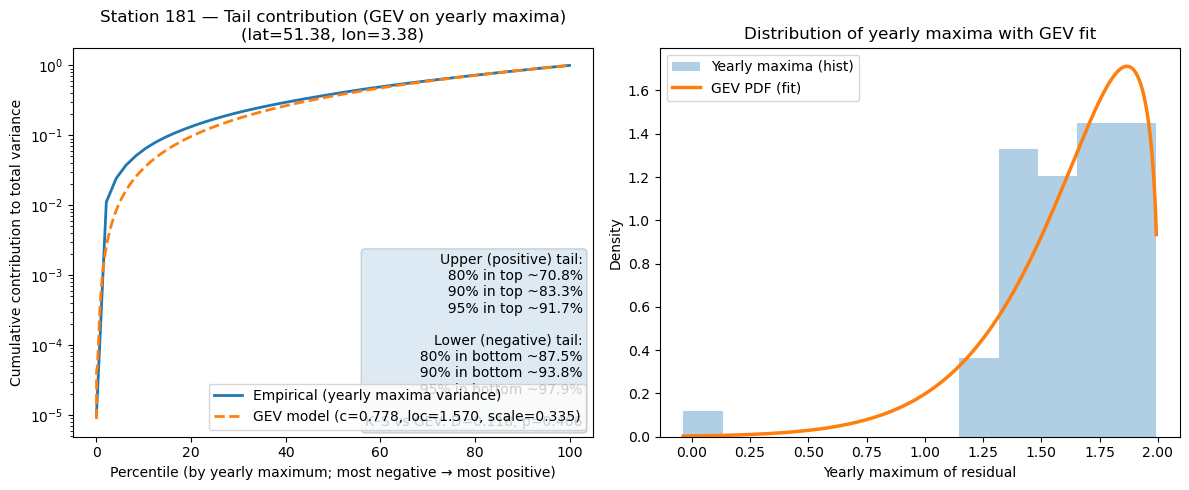

Station 181 — GEV on yearly maxima:
  params: c=0.777963, loc=1.569916, scale=0.334920
  KS D=0.1181, p=0.4662
Skipping station 183: only 17 yearly maxima (need ≥ 40).
Skipping station 19: only 26 yearly maxima (need ≥ 40).


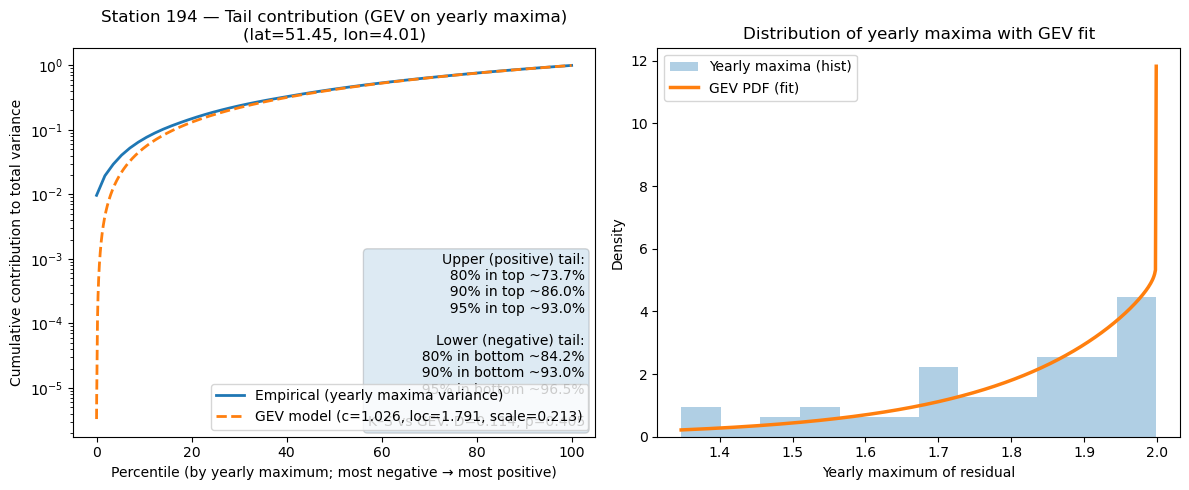

Station 194 — GEV on yearly maxima:
  params: c=1.025822, loc=1.790855, scale=0.213222
  KS D=0.1142, p=0.4050
Skipping station 195: only 38 yearly maxima (need ≥ 40).
Skipping station 196: only 13 yearly maxima (need ≥ 40).
Skipping station 197: only 17 yearly maxima (need ≥ 40).


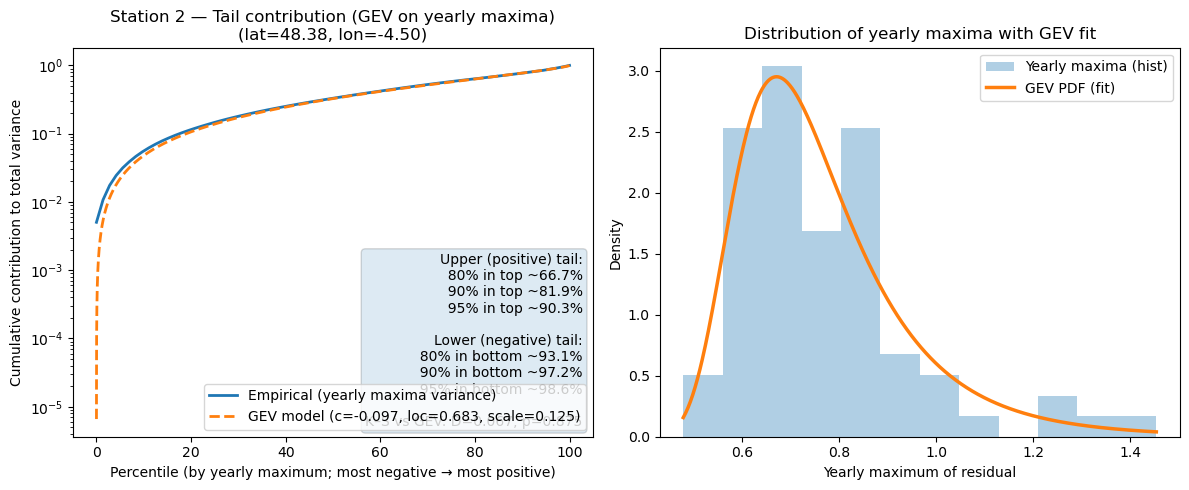

Station 2 — GEV on yearly maxima:
  params: c=-0.097023, loc=0.682688, scale=0.125321
  KS D=0.0672, p=0.8746


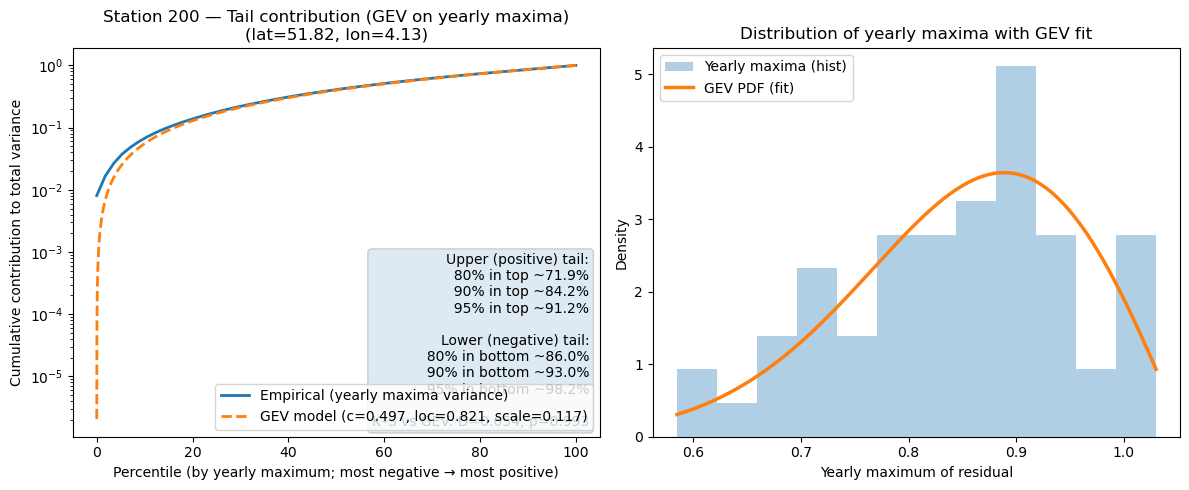

Station 200 — GEV on yearly maxima:
  params: c=0.496654, loc=0.820533, scale=0.117481
  KS D=0.0539, p=0.9926


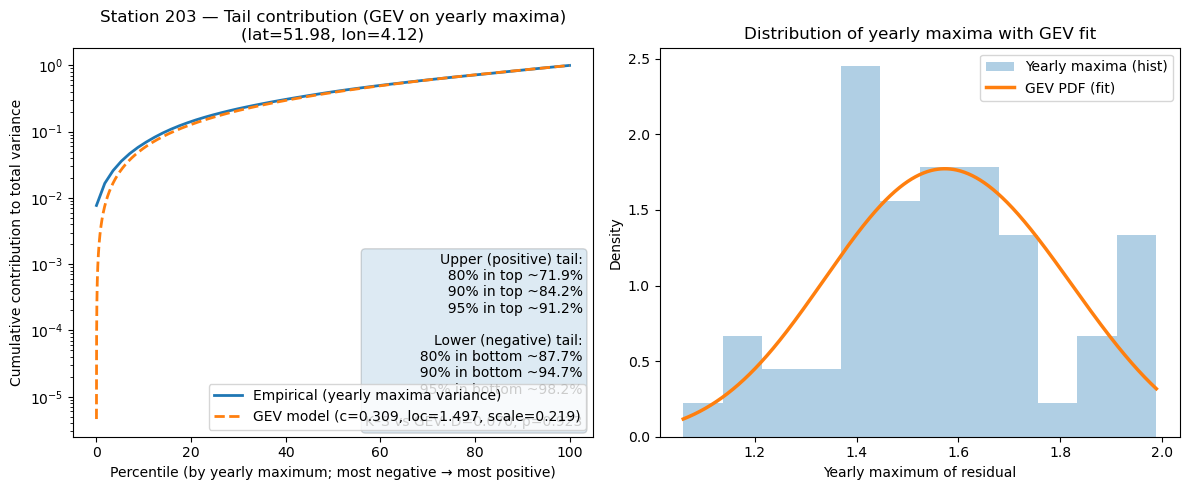

Station 203 — GEV on yearly maxima:
  params: c=0.308613, loc=1.496905, scale=0.218971
  KS D=0.0695, p=0.9234
Skipping station 205: only 17 yearly maxima (need ≥ 40).
Skipping station 208: only 19 yearly maxima (need ≥ 40).
Skipping station 209: only 31 yearly maxima (need ≥ 40).
Skipping station 21: only 18 yearly maxima (need ≥ 40).


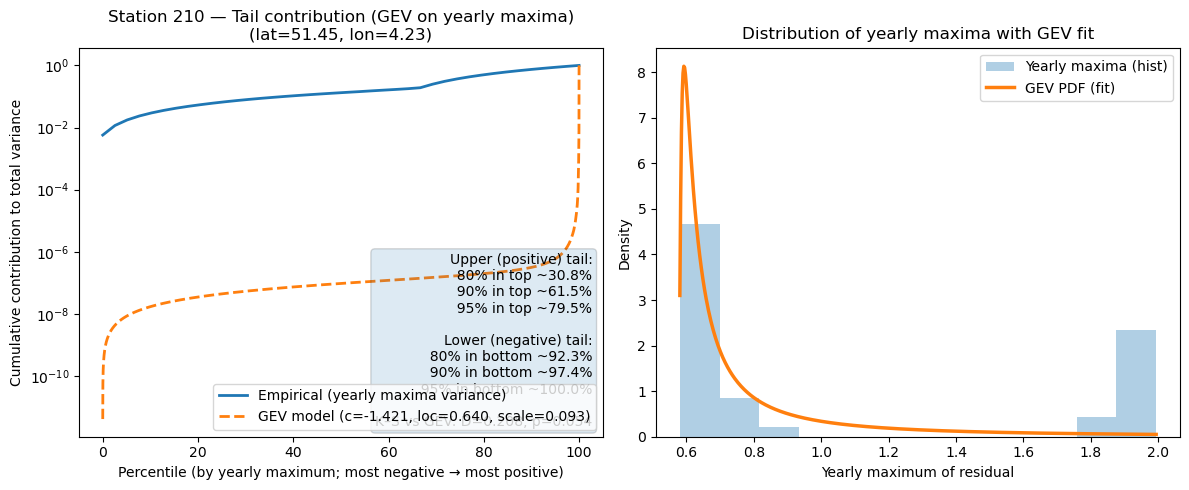

Station 210 — GEV on yearly maxima:
  params: c=-1.421070, loc=0.639975, scale=0.092840
  KS D=0.2078, p=0.0541
Skipping station 216: only 23 yearly maxima (need ≥ 40).
Skipping station 22: only 18 yearly maxima (need ≥ 40).
Skipping station 226: only 32 yearly maxima (need ≥ 40).
Skipping station 227: only 33 yearly maxima (need ≥ 40).
Skipping station 23: only 15 yearly maxima (need ≥ 40).


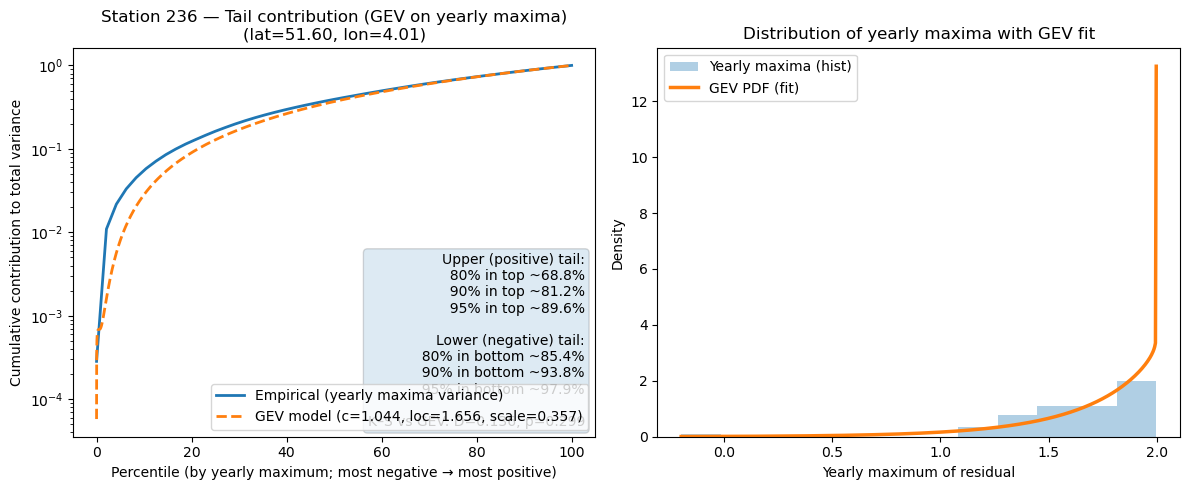

Station 236 — GEV on yearly maxima:
  params: c=1.044160, loc=1.655805, scale=0.356966
  KS D=0.1358, p=0.2989
Skipping station 237: only 27 yearly maxima (need ≥ 40).
Skipping station 238: only 13 yearly maxima (need ≥ 40).


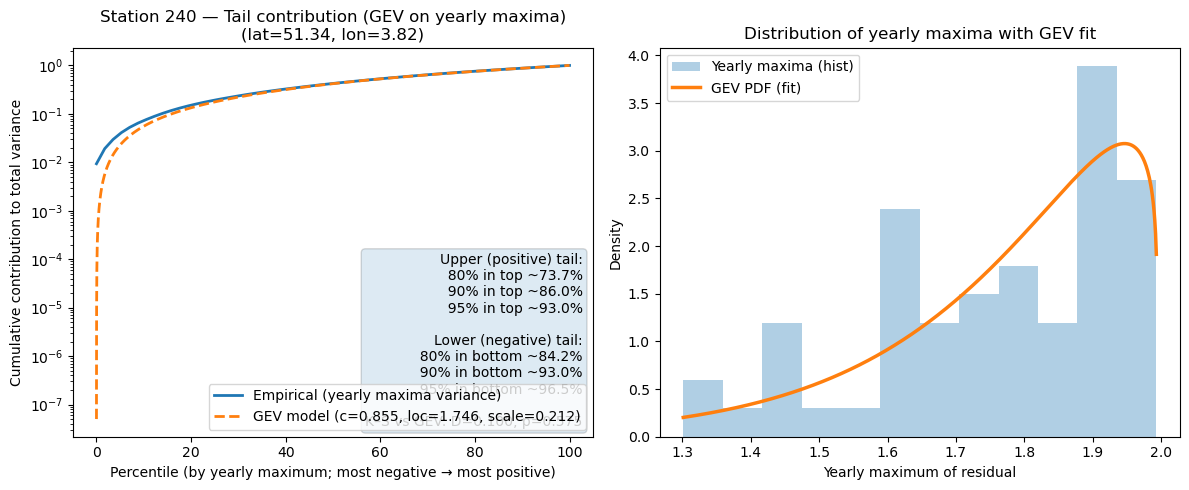

Station 240 — GEV on yearly maxima:
  params: c=0.854588, loc=1.746013, scale=0.212464
  KS D=0.0999, p=0.5747
Skipping station 242: only 15 yearly maxima (need ≥ 40).


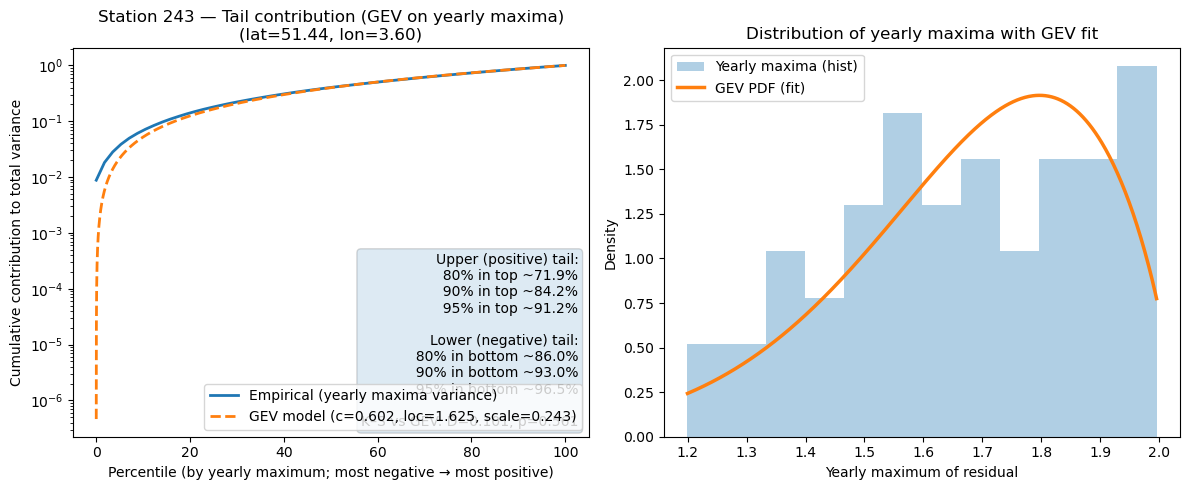

Station 243 — GEV on yearly maxima:
  params: c=0.602167, loc=1.625260, scale=0.243133
  KS D=0.1010, p=0.5605
Skipping station 245: only 29 yearly maxima (need ≥ 40).


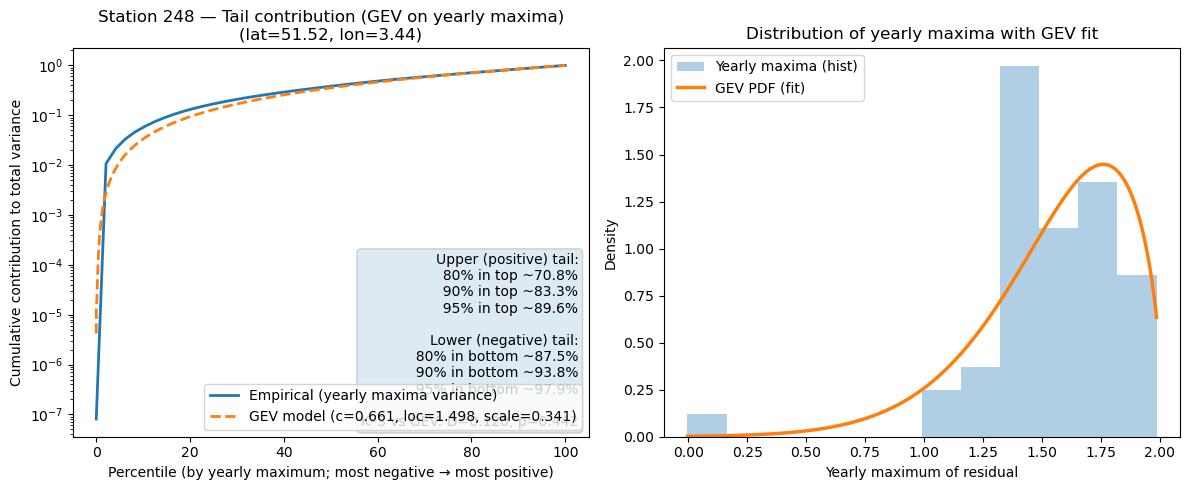

Station 248 — GEV on yearly maxima:
  params: c=0.660560, loc=1.497545, scale=0.340859
  KS D=0.1204, p=0.4421
Skipping station 251: only 27 yearly maxima (need ≥ 40).
Skipping station 254: only 33 yearly maxima (need ≥ 40).


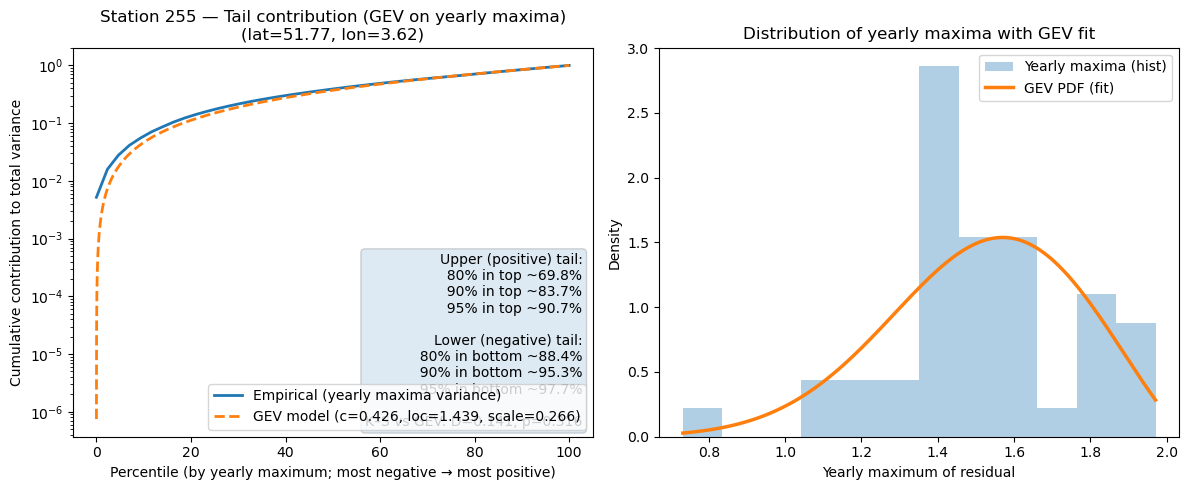

Station 255 — GEV on yearly maxima:
  params: c=0.425829, loc=1.438637, scale=0.266181
  KS D=0.1409, p=0.3163
Skipping station 259: only 33 yearly maxima (need ≥ 40).
Skipping station 260: only 31 yearly maxima (need ≥ 40).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

TARGET_VAR = "residual"
N_STATIONS = 100
MIN_YEARS = 40  # need enough annual maxima for a stable fit

def top_percent_for_share(cum, p_axis, target):
    bottom_allow = 1.0 - target
    i = np.searchsorted(cum, bottom_allow, side="left")
    return 100.0 - p_axis[i] if i < len(p_axis) else np.nan

def bottom_percent_for_share(cum, p_axis, target):
    i = np.searchsorted(cum, target, side="left")
    return p_axis[i] if i < len(p_axis) else np.nan

stations = np.array(ds["station"].values)[:N_STATIONS]

for s in stations:
    # --- YEARLY maxima for this station ---
    da = ds[TARGET_VAR].sel(station=s)
    yearly_max = da.resample(valid_time="Y").max(skipna=True)  # <-- yearly
    x = yearly_max.values
    x = x[np.isfinite(x)]
    if x.size < MIN_YEARS:
        print(f"Skipping station {s}: only {x.size} yearly maxima (need ≥ {MIN_YEARS}).")
        continue

    # sort by raw yearly maxima (negatives first, positives last)
    order = np.argsort(x)
    x_sorted = x[order]

    # cumulative contribution to total variance
    x2 = x_sorted**2
    cum = np.cumsum(x2) / np.sum(x2)
    p = np.linspace(0, 100, len(cum))  # 0 = most negative yearly max, 100 = most positive

    # tail concentration metrics
    targets = (0.80, 0.90, 0.95)
    top_needed = {t: top_percent_for_share(cum, p, t) for t in targets}
    bot_needed = {t: bottom_percent_for_share(cum, p, t) for t in targets}

    # --- GEV fit on yearly maxima ---
    c_shape, loc, scale = st.genextreme.fit(x)  # (c, loc, scale)

    # KS goodness-of-fit on yearly maxima
    D_gev, p_gev = st.kstest(x, 'genextreme', args=(c_shape, loc, scale))

    # Monte Carlo model curve from fitted GEV (for the left panel)
    rng = np.random.default_rng(12345)
    n_sim = min(200_000, max(40_000, 30 * len(x)))
    x_sim = st.genextreme.rvs(c_shape, loc=loc, scale=scale, size=n_sim, random_state=rng)
    x2_sim = np.sort(x_sim)**2
    cum_sim = np.cumsum(x2_sim) / np.sum(x2_sim)
    p_sim = np.linspace(0, 100, len(cum_sim))

    # --- Right panel: PDF (hist + GEV PDF) ---
    x_min, x_max = np.min(x), np.max(x)
    xs = np.linspace(x_min, x_max, 600)
    gev_pdf = st.genextreme.pdf(xs, c_shape, loc=loc, scale=scale)

    # --- Figure with two panels side-by-side ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    # Left: cumulative contribution curve + GEV model
    ax1.plot(p, cum, linewidth=2, label="Empirical (yearly maxima variance)")
    ax1.plot(p_sim, cum_sim, linestyle="--", linewidth=2,
             label=f"GEV model (c={c_shape:.3f}, loc={loc:.3f}, scale={scale:.3f})")
    ax1.set_yscale('log')
    ax1.set_xlabel("Percentile (by yearly maximum; most negative → most positive)")
    ax1.set_ylabel("Cumulative contribution to total variance")
    ax1.legend()

    txt = (
        "Upper (positive) tail:\n"
        + "\n".join([f"  {int(t*100)}% in top ~{top_needed[t]:.1f}%" for t in targets])
        + "\n\nLower (negative) tail:\n"
        + "\n".join([f"  {int(t*100)}% in bottom ~{bot_needed[t]:.1f}%"
                     for t in targets])
        + f"\n\nK–S vs GEV: D={D_gev:.3f}, p={p_gev:.3f}"
    )
    ax1.text(0.98, 0.02, txt, transform=ax1.transAxes,
             ha='right', va='bottom', bbox=dict(boxstyle='round', alpha=0.15))

    lat = ds["station_latitude"].sel(station=s).item()
    lon = ds["station_longitude"].sel(station=s).item()
    ax1.set_title(f"Station {int(s)} — Tail contribution (GEV on yearly maxima)\n"
                  f"(lat={lat:.2f}, lon={lon:.2f})")

    # Right: histogram + GEV PDF
    ax2.hist(x, bins=max(12, int(np.sqrt(len(x)))), density=True, alpha=0.35, label="Yearly maxima (hist)")
    ax2.plot(xs, gev_pdf, linewidth=2.5, label="GEV PDF (fit)")
    ax2.set_xlabel("Yearly maximum of residual")
    ax2.set_ylabel("Density")
    ax2.legend()
    ax2.set_title("Distribution of yearly maxima with GEV fit")

    fig.tight_layout()
    plt.show()

    # console summary
    print(f"Station {int(s)} — GEV on yearly maxima:")
    print(f"  params: c={c_shape:.6f}, loc={loc:.6f}, scale={scale:.6f}")
    print(f"  KS D={D_gev:.4f}, p={p_gev:.4f}")

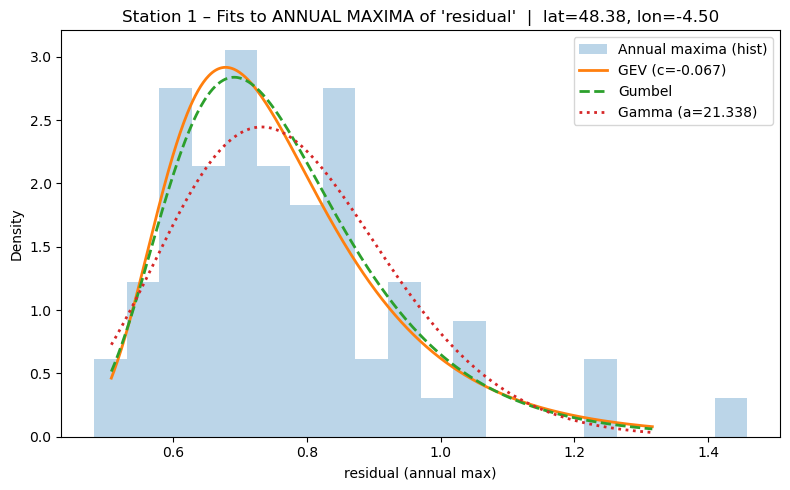

Station 1 params (annual maxima):
  GEV:    c=-0.066898, loc=0.686735, scale=0.126416
  Gumbel: loc=0.691408, scale=0.129620
  Gamma:  a=21.337512, loc=0.000000, scale=0.036024
------------------------------------------------------------


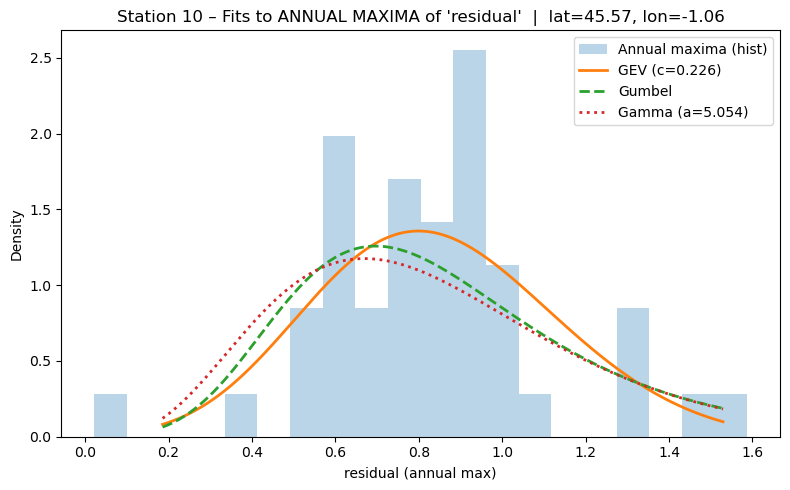

Station 10 params (annual maxima):
  GEV:    c=0.226203, loc=0.729844, scale=0.278690
  Gumbel: loc=0.696444, scale=0.292480
  Gamma:  a=5.054302, loc=0.000000, scale=0.165158
------------------------------------------------------------


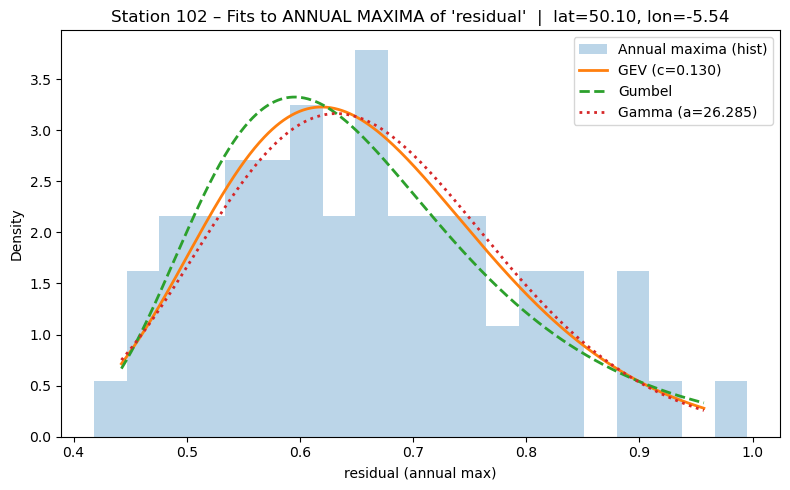

Station 102 params (annual maxima):
  GEV:    c=0.130419, loc=0.603166, scale=0.115003
  Gumbel: loc=0.595309, scale=0.110645
  Gamma:  a=26.284516, loc=0.000000, scale=0.025001
------------------------------------------------------------


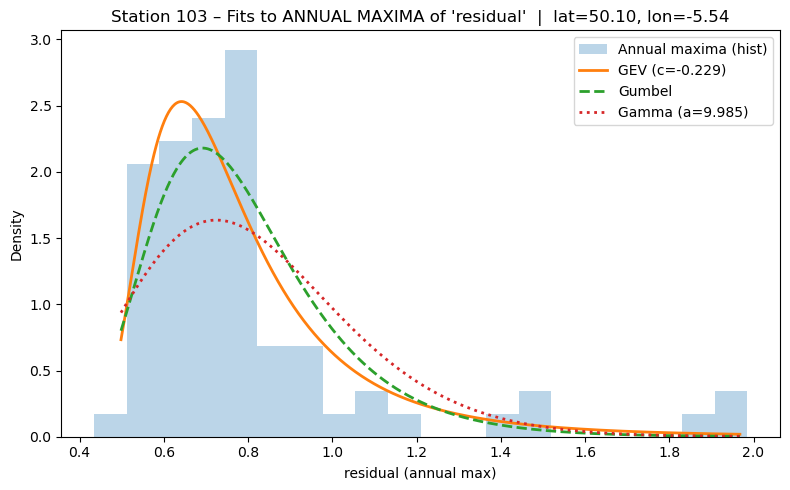

Station 103 params (annual maxima):
  GEV:    c=-0.228568, loc=0.671869, scale=0.148922
  Gumbel: loc=0.691777, scale=0.168764
  Gamma:  a=9.985089, loc=0.000000, scale=0.080607
------------------------------------------------------------


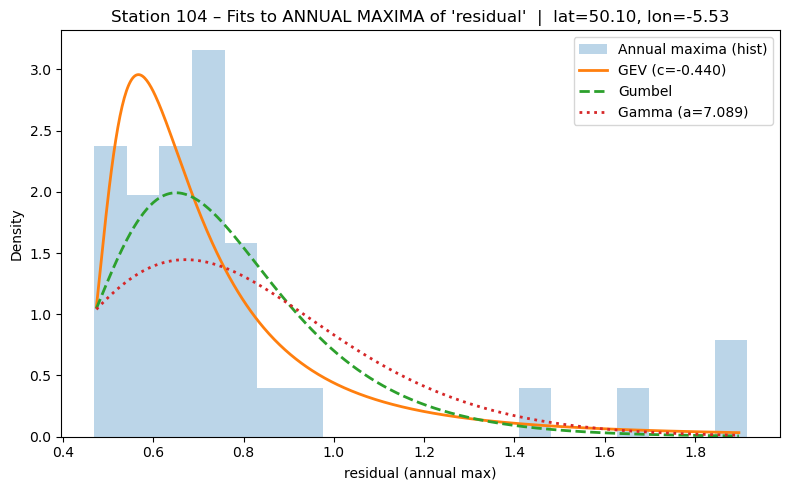

Station 104 params (annual maxima):
  GEV:    c=-0.440297, loc=0.612946, scale=0.135504
  Gumbel: loc=0.650535, scale=0.184711
  Gamma:  a=7.088856, loc=0.000000, scale=0.110314
------------------------------------------------------------


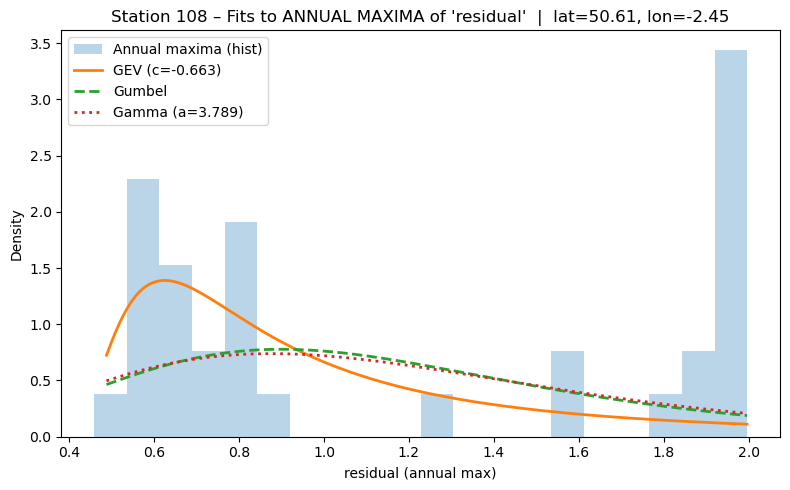

Station 108 params (annual maxima):
  GEV:    c=-0.663300, loc=0.762085, scale=0.317954
  Gumbel: loc=0.899218, scale=0.473142
  Gamma:  a=3.789432, loc=0.000000, scale=0.313872
------------------------------------------------------------


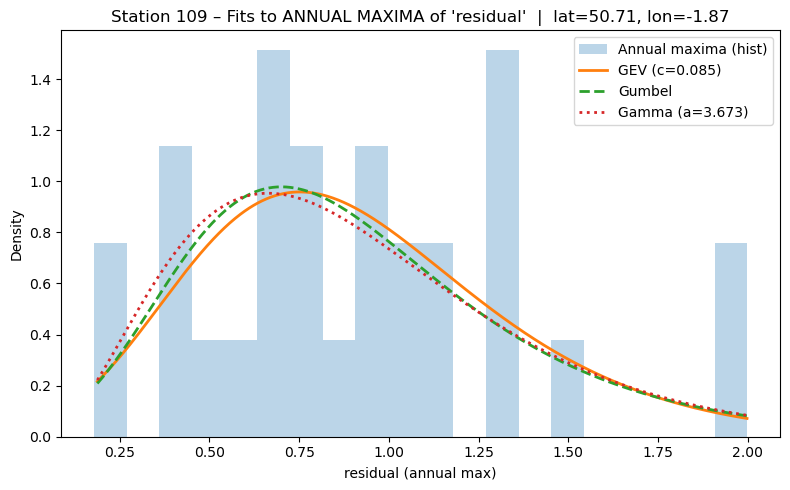

Station 109 params (annual maxima):
  GEV:    c=0.084587, loc=0.717643, scale=0.385270
  Gumbel: loc=0.700273, scale=0.376033
  Gamma:  a=3.672628, loc=0.000000, scale=0.248167
------------------------------------------------------------


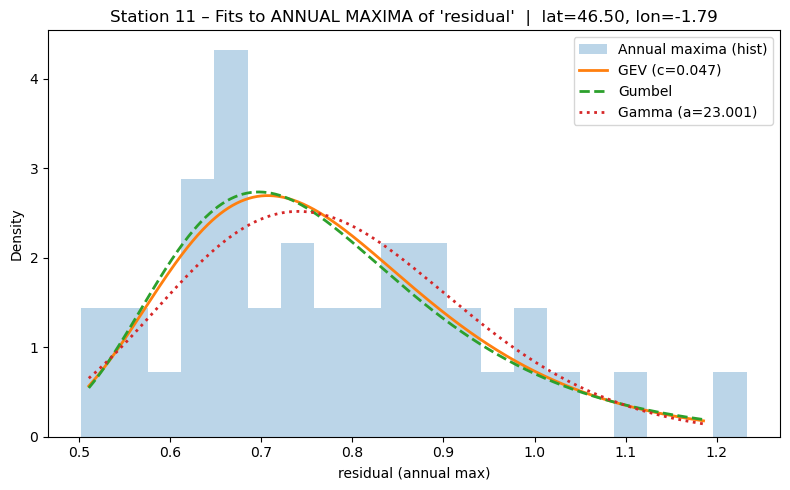

Station 11 params (annual maxima):
  GEV:    c=0.047052, loc=0.700599, scale=0.136738
  Gumbel: loc=0.697164, scale=0.134564
  Gamma:  a=23.001300, loc=0.000000, scale=0.033664
------------------------------------------------------------
Skipping station 110: only 0 annual maxima (need ≥ 15).


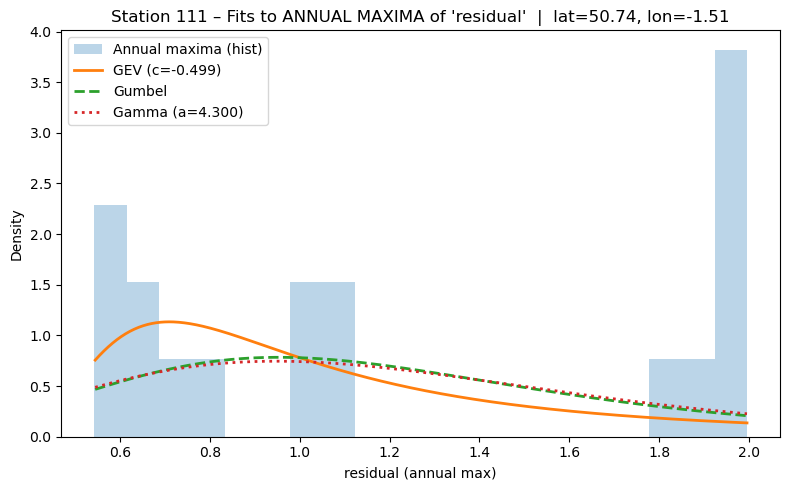

Station 111 params (annual maxima):
  GEV:    c=-0.498903, loc=0.842248, scale=0.361268
  Gumbel: loc=0.953160, scale=0.469226
  Gamma:  a=4.300394, loc=0.000000, scale=0.287192
------------------------------------------------------------


In [ ]:
# Fit GEV, Gumbel, and Gamma to ANNUAL MAXIMA for the first 10 stations and plot curves
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

# --- config ---
TARGET_VAR = "residual"   # change if needed
N_STATIONS = 10
HIST_BINS = 20            # fewer bins; annual maxima sample is smaller
MIN_YEARS = 15            # skip stations with too few annual maxima

# ds = ...  # your Dataset in memory

if TARGET_VAR not in ds.data_vars:
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

def _meta_for_station(i):
    lat = lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

stations = np.array(ds["station"].values)[:N_STATIONS]

for s in stations:
    # --- 1) extract annual maxima for this station ---
    # If your dataset already has a 'year' coord, the groupby below still works.
    series = ds[TARGET_VAR].sel(station=s)
    annual_max = series.groupby("valid_time.year").max(dim="valid_time").values
    x = np.asarray(annual_max)
    x = x[np.isfinite(x)]

    if x.size < MIN_YEARS:
        print(f"Skipping station {s}: only {x.size} annual maxima (need ≥ {MIN_YEARS}).")
        continue

    # --- 2) fit distributions to extremes (maxima) ---
    # GEV (c, loc, scale)
    gev_params = st.genextreme.fit(x)
    # Gumbel (loc, scale)
    gum_params = st.gumbel_r.fit(x)
    # Gamma: annual maxima should be ≥ 0 in many cases; to stabilize fit, fix loc=0
    # Remove nonpositive values if you want strictly positive support:
    # x = x[x > 0]
    gam_params = st.gamma.fit(x, floc=0)  # (a, loc=0, scale)

    # --- 3) plotting ---
    x_min, x_max = np.percentile(x, [1, 99])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        x_min, x_max = x.min(), x.max()
        if x_min == x_max:
            print(f"Skipping station {s}: degenerate annual maxima.")
            continue

    xs = np.linspace(x_min, x_max, 600)

    gev_pdf = st.genextreme.pdf(xs, *gev_params)
    gum_pdf = st.gumbel_r.pdf(xs, *gum_params)
    gam_pdf = st.gamma.pdf(xs, *gam_params)

    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=HIST_BINS, density=True, alpha=0.3, label="Annual maxima (hist)")
    plt.plot(xs, gev_pdf, linewidth=2, label=f"GEV (c={gev_params[0]:.3f})")
    plt.plot(xs, gum_pdf, linewidth=2, linestyle="--", label="Gumbel")
    plt.plot(xs, gam_pdf, linewidth=2, linestyle=":", label=f"Gamma (a={gam_params[0]:.3f})")

    lat, lon = _meta_for_station(s)
    meta = f"  |  lat={lat:.2f}, lon={lon:.2f}" if (lat is not None and lon is not None) else ""
    plt.title(f"Station {int(s)} – Fits to ANNUAL MAXIMA of '{TARGET_VAR}'{meta}")
    plt.xlabel(f"{TARGET_VAR} (annual max)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Station {int(s)} params (annual maxima):")
    print(f"  GEV:    c={gev_params[0]:.6f}, loc={gev_params[1]:.6f}, scale={gev_params[2]:.6f}")
    print(f"  Gumbel: loc={gum_params[0]:.6f}, scale={gum_params[1]:.6f}")
    print(f"  Gamma:  a={gam_params[0]:.6f}, loc={gam_params[1]:.6f}, scale={gam_params[2]:.6f}")
    print("-" * 60)


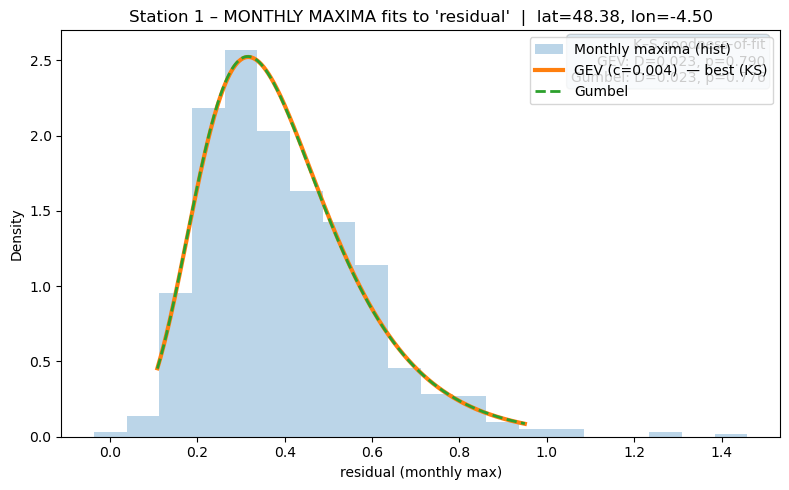

Station 1 params (monthly maxima):
  GEV:    c=0.004427, loc=0.315913, scale=0.145817  |  KS D=0.0229, p=0.7903
  Gumbel: loc=0.315561, scale=0.145624  |  KS D=0.0232, p=0.7755
  Gamma:  skipped (monthly maxima not positive)
  -> Best by KS: GEV
------------------------------------------------------------


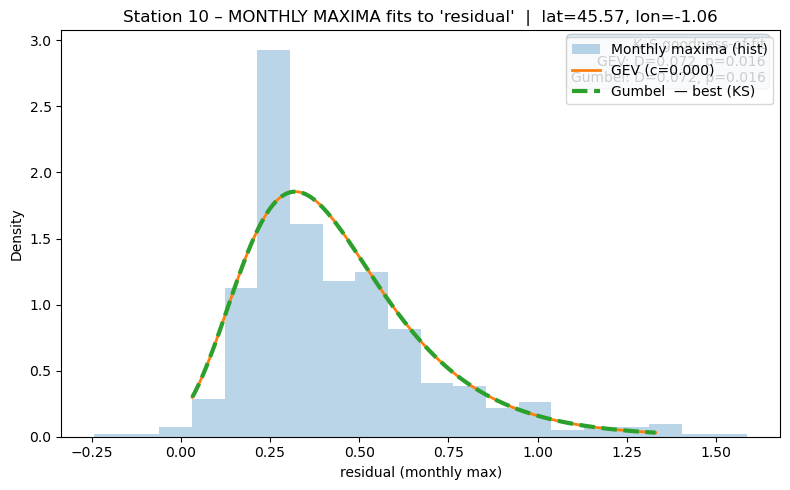

Station 10 params (monthly maxima):
  GEV:    c=0.000255, loc=0.320571, scale=0.198341  |  KS D=0.0722, p=0.0165
  Gumbel: loc=0.320568, scale=0.198371  |  KS D=0.0722, p=0.0165
  Gamma:  skipped (monthly maxima not positive)
  -> Best by KS: Gumbel
------------------------------------------------------------


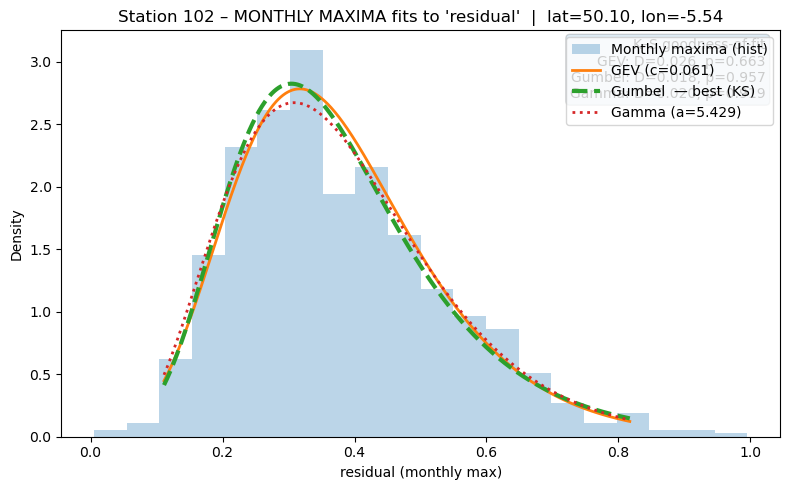

Station 102 params (monthly maxima):
  GEV:    c=0.061218, loc=0.308571, scale=0.132428  |  KS D=0.0264, p=0.6634
  Gumbel: loc=0.304276, scale=0.130238  |  KS D=0.0184, p=0.9568
  Gamma:  a=5.429376, loc=0.000000, scale=0.069601  |  KS D=0.0200, p=0.9187
  -> Best by KS: Gumbel
------------------------------------------------------------


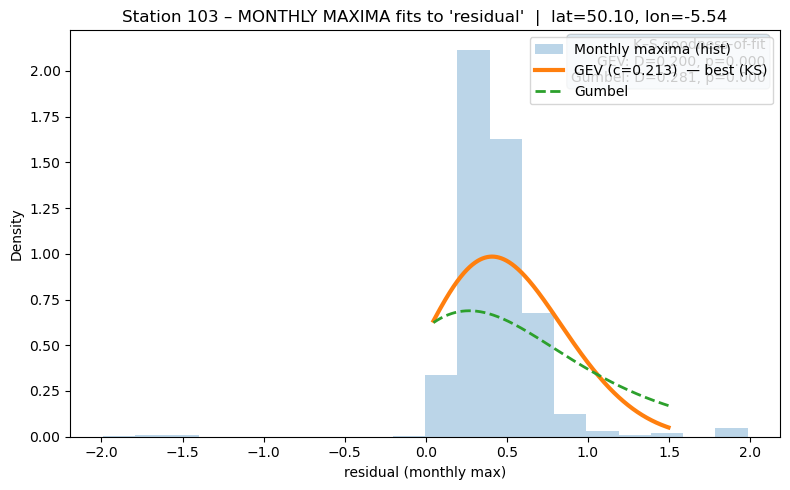

Station 103 params (monthly maxima):
  GEV:    c=0.213338, loc=0.319296, scale=0.382903  |  KS D=0.1997, p=0.0000
  Gumbel: loc=0.268562, scale=0.534239  |  KS D=0.2806, p=0.0000
  Gamma:  skipped (monthly maxima not positive)
  -> Best by KS: GEV
------------------------------------------------------------


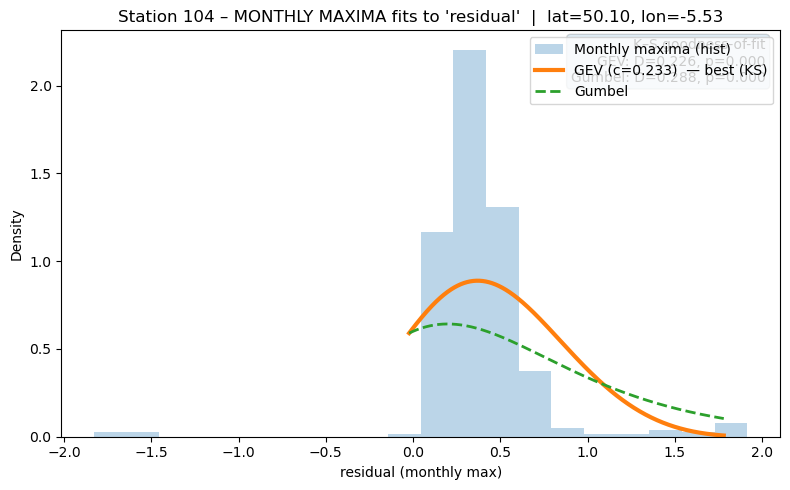

Station 104 params (monthly maxima):
  GEV:    c=0.232725, loc=0.260629, scale=0.426359  |  KS D=0.2259, p=0.0000
  Gumbel: loc=0.198326, scale=0.572841  |  KS D=0.2879, p=0.0000
  Gamma:  skipped (monthly maxima not positive)
  -> Best by KS: GEV
------------------------------------------------------------


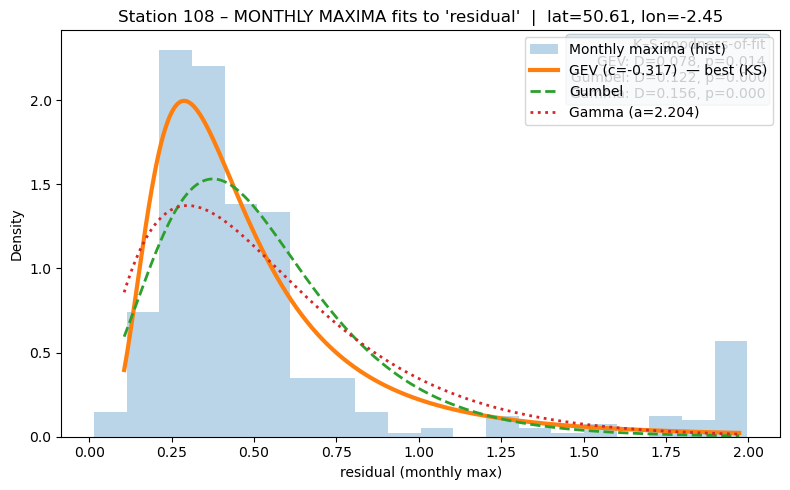

Station 108 params (monthly maxima):
  GEV:    c=-0.317078, loc=0.338522, scale=0.192972  |  KS D=0.0775, p=0.0140
  Gumbel: loc=0.375009, scale=0.240228  |  KS D=0.1221, p=0.0000
  Gamma:  a=2.204423, loc=0.000000, scale=0.247333  |  KS D=0.1556, p=0.0000
  -> Best by KS: GEV
------------------------------------------------------------


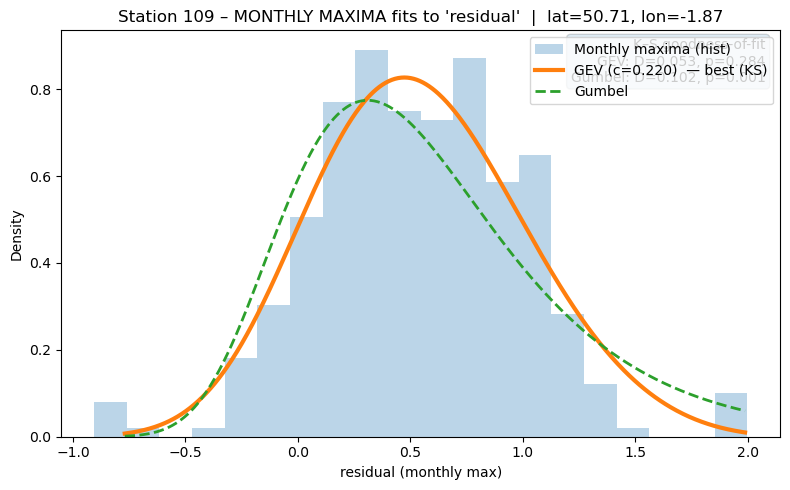

Station 109 params (monthly maxima):
  GEV:    c=0.219537, loc=0.363111, scale=0.456712  |  KS D=0.0531, p=0.2839
  Gumbel: loc=0.309931, scale=0.475110  |  KS D=0.1023, p=0.0015
  Gamma:  skipped (monthly maxima not positive)
  -> Best by KS: GEV
------------------------------------------------------------


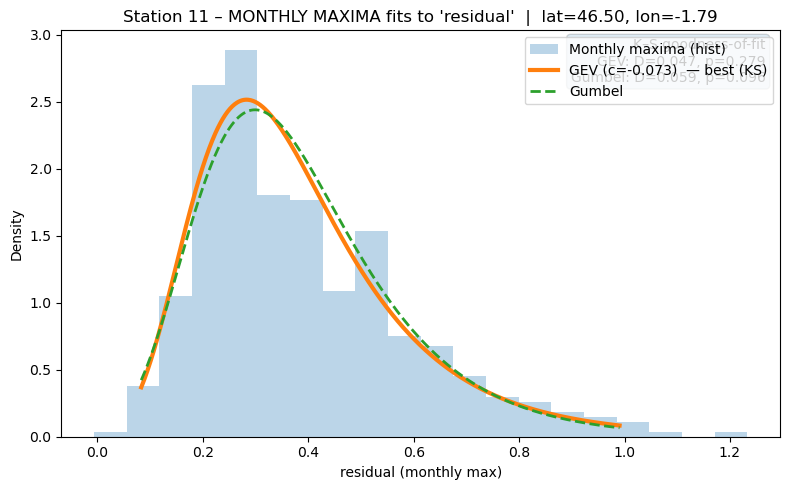

Station 11 params (monthly maxima):
  GEV:    c=-0.072559, loc=0.293130, scale=0.146579  |  KS D=0.0474, p=0.2792
  Gumbel: loc=0.298876, scale=0.150726  |  KS D=0.0590, p=0.0958
  Gamma:  skipped (monthly maxima not positive)
  -> Best by KS: GEV
------------------------------------------------------------
Skipping station 110: only 0 monthly maxima (need ≥ 60).


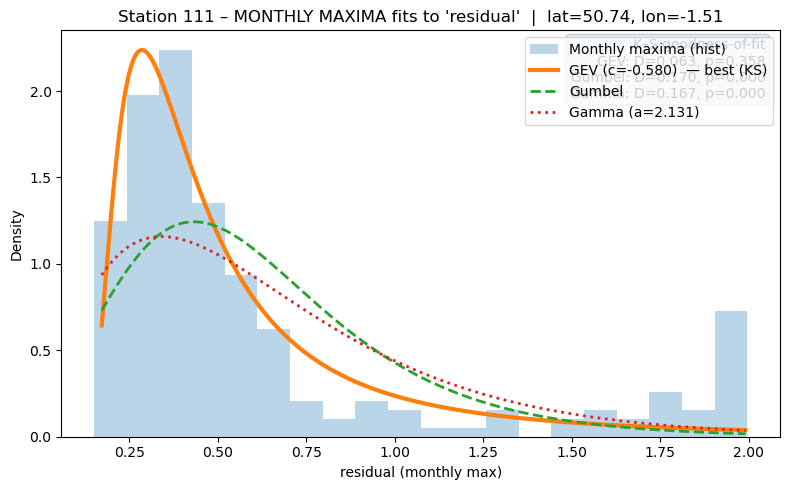

Station 111 params (monthly maxima):
  GEV:    c=-0.579596, loc=0.361547, scale=0.189613  |  KS D=0.0634, p=0.3579
  Gumbel: loc=0.432291, scale=0.295775  |  KS D=0.1704, p=0.0000
  Gamma:  a=2.130552, loc=0.000000, scale=0.301408  |  KS D=0.1665, p=0.0000
  -> Best by KS: GEV
------------------------------------------------------------


In [ ]:
# Fit GEV, Gumbel, and Gamma to MONTHLY MAXIMA for the first 10 stations,
# run K-S tests, and annotate the plot with the goodness-of-fit results.
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

# --- config ---
TARGET_VAR = "residual"
N_STATIONS = 10
HIST_BINS = 20
MIN_MONTHS = 60           # require enough months for a meaningful fit
GAMMA_REQUIRE_POSITIVE = True  # only fit/test Gamma if all monthly maxima > 0

if TARGET_VAR not in ds.data_vars:
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

def _meta_for_station(i):
    lat = lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

stations = np.array(ds["station"].values)[:N_STATIONS]

for s in stations:
    # --- 1) monthly maxima ---
    series = ds[TARGET_VAR].sel(station=s)
    monthly_max = series.resample(valid_time="M").max(skipna=True)

    x = np.asarray(monthly_max.values)
    x = x[np.isfinite(x)]

    if x.size < MIN_MONTHS:
        print(f"Skipping station {s}: only {x.size} monthly maxima (need ≥ {MIN_MONTHS}).")
        continue
    if np.all(x == x[0]):
        print(f"Skipping station {s}: degenerate monthly maxima (all equal).")
        continue

    # --- 2) fit distributions ---
    gev_params = st.genextreme.fit(x)           # (c, loc, scale)
    gum_params = st.gumbel_r.fit(x)             # (loc, scale)

    gamma_ok = (np.all(x > 0) if GAMMA_REQUIRE_POSITIVE else np.any(x > 0))
    gam_params = None
    if gamma_ok:
        # If some are ≤0 but you still want gamma, fit to positives only:
        x_for_gamma = x if np.all(x > 0) else x[x > 0]
        gam_params = st.gamma.fit(x_for_gamma, floc=0)  # (a, 0, scale)

    # --- 3) K-S tests (use the same sample for each tested distribution) ---
    ks_results = {}
    D_gev, p_gev = st.kstest(x, 'genextreme', args=gev_params)
    ks_results['GEV'] = (D_gev, p_gev)

    D_gum, p_gum = st.kstest(x, 'gumbel_r', args=gum_params)
    ks_results['Gumbel'] = (D_gum, p_gum)

    if gam_params is not None and np.all(x > 0):   # fair comparison on same sample
        D_gam, p_gam = st.kstest(x, 'gamma', args=gam_params)
        ks_results['Gamma'] = (D_gam, p_gam)
    elif gam_params is not None:
        # If we fitted gamma on positives-only, run KS on that subset and label accordingly
        x_pos = x[x > 0]
        D_gam, p_gam = st.kstest(x_pos, 'gamma', args=gam_params)
        ks_results['Gamma (on x>0)'] = (D_gam, p_gam)
    else:
        D_gam = p_gam = None

    # choose best by smallest D
    best_name = min(ks_results.items(), key=lambda kv: kv[1][0])[0]

    # --- 4) PDFs for plotting ---
    x_min, x_max = np.percentile(x, [1, 99])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        x_min, x_max = float(x.min()), float(x.max()) + 1e-9
    xs = np.linspace(x_min, x_max, 600)

    pdfs = {
        'GEV': st.genextreme.pdf(xs, *gev_params),
        'Gumbel': st.gumbel_r.pdf(xs, *gum_params),
    }
    if gam_params is not None:
        pdfs['Gamma'] = st.gamma.pdf(xs, *gam_params)

    # --- 5) plot ---
    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=HIST_BINS, density=True, alpha=0.3, label="Monthly maxima (hist)")

    # plot each curve; make the "best" a bit thicker
    for name, pdf in pdfs.items():
        lw = 3.0 if name in best_name else 2.0
        ls = {'GEV':'-', 'Gumbel':'--', 'Gamma':':'}.get(name, '-.')
        if name == 'GEV':
            label = f"GEV (c={gev_params[0]:.3f})"
        elif name == 'Gumbel':
            label = "Gumbel"
        elif name.startswith('Gamma'):
            label = f"Gamma (a={gam_params[0]:.3f})" if gam_params is not None else "Gamma"
        else:
            label = name
        if name in best_name:
            label += "  — best (KS)"
        plt.plot(xs, pdf, linestyle=ls, linewidth=lw, label=label)

    # KS annotation box
    lines = [f"{k}: D={v[0]:.3f}, p={v[1]:.3f}" for k, v in ks_results.items()]
    ks_text = "K–S goodness-of-fit\n" + "\n".join(lines)
    ax = plt.gca()
    ax.text(
        0.98, 0.98, ks_text,
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', alpha=0.15)
    )

    # titles/labels
    lat, lon = _meta_for_station(s)
    meta = f"  |  lat={lat:.2f}, lon={lon:.2f}" if (lat is not None and lon is not None) else ""
    plt.title(f"Station {int(s)} – MONTHLY MAXIMA fits to '{TARGET_VAR}'{meta}")
    plt.xlabel(f"{TARGET_VAR} (monthly max)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # print fitted params and KS in console too
    print(f"Station {int(s)} params (monthly maxima):")
    print(f"  GEV:    c={gev_params[0]:.6f}, loc={gev_params[1]:.6f}, scale={gev_params[2]:.6f}  |  KS D={D_gev:.4f}, p={p_gev:.4f}")
    print(f"  Gumbel: loc={gum_params[0]:.6f}, scale={gum_params[1]:.6f}  |  KS D={D_gum:.4f}, p={p_gum:.4f}")
    if gam_params is not None:
        print(f"  Gamma:  a={gam_params[0]:.6f}, loc={gam_params[1]:.6f}, scale={gam_params[2]:.6f}  |  KS D={D_gam:.4f}, p={p_gam:.4f}")
    else:
        print("  Gamma:  skipped (monthly maxima not positive)")
    print(f"  -> Best by KS: {best_name}")
    print("-" * 60)


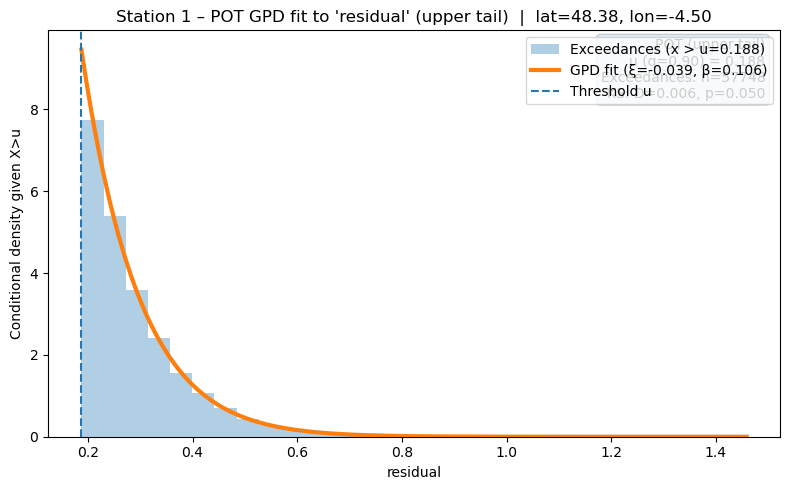

Station 1 POT GPD (upper tail):
  Threshold u (q=0.90): 0.187585
  Exceedances: n=57748/577480 (10.0%)
  GPD params: shape ξ=-0.039189, scale β=0.105732 (loc fixed at 0)
  KS test: D=0.005647, p=0.050119
------------------------------------------------------------


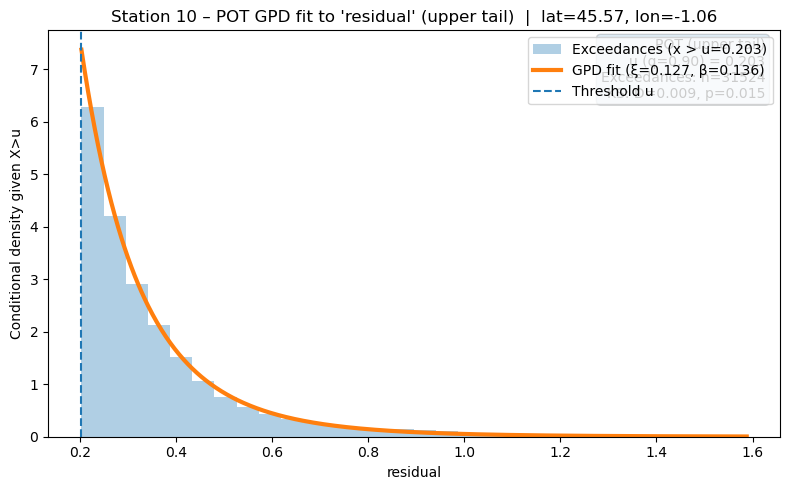

Station 10 POT GPD (upper tail):
  Threshold u (q=0.90): 0.203115
  Exceedances: n=31524/315236 (10.0%)
  GPD params: shape ξ=0.126534, scale β=0.135576 (loc fixed at 0)
  KS test: D=0.008784, p=0.015337
------------------------------------------------------------


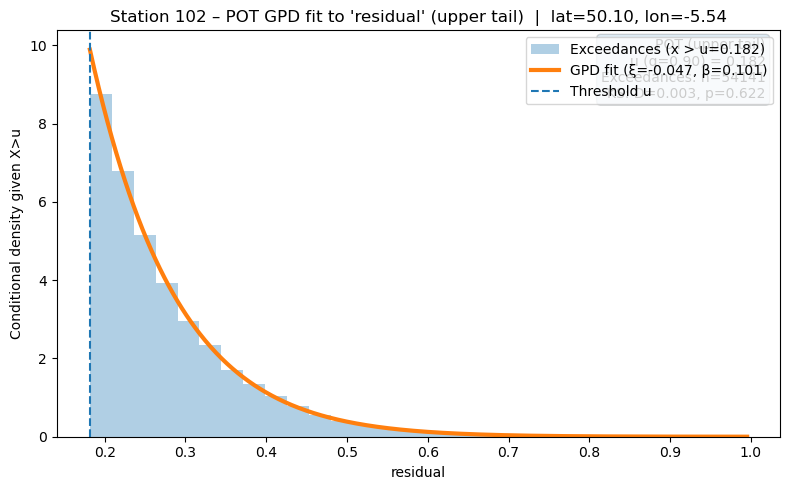

Station 102 POT GPD (upper tail):
  Threshold u (q=0.90): 0.181672
  Exceedances: n=54141/541411 (10.0%)
  GPD params: shape ξ=-0.046905, scale β=0.101122 (loc fixed at 0)
  KS test: D=0.003233, p=0.622144
------------------------------------------------------------


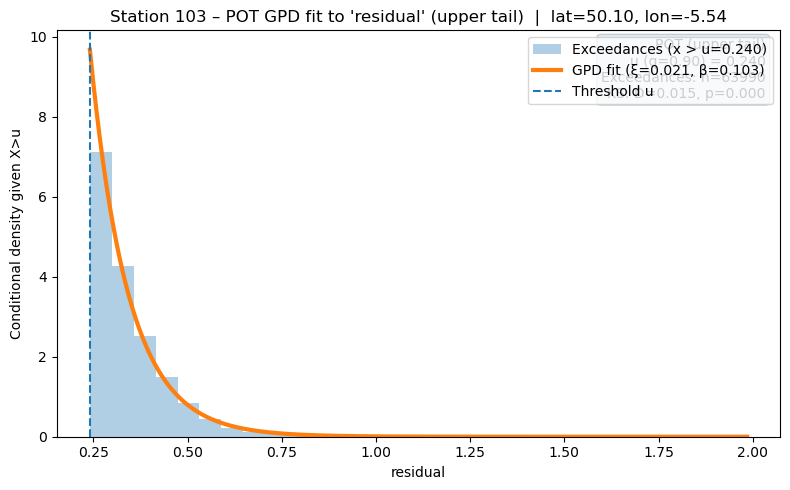

Station 103 POT GPD (upper tail):
  Threshold u (q=0.90): 0.240467
  Exceedances: n=63990/639894 (10.0%)
  GPD params: shape ξ=0.020502, scale β=0.103399 (loc fixed at 0)
  KS test: D=0.015379, p=0.000000
------------------------------------------------------------


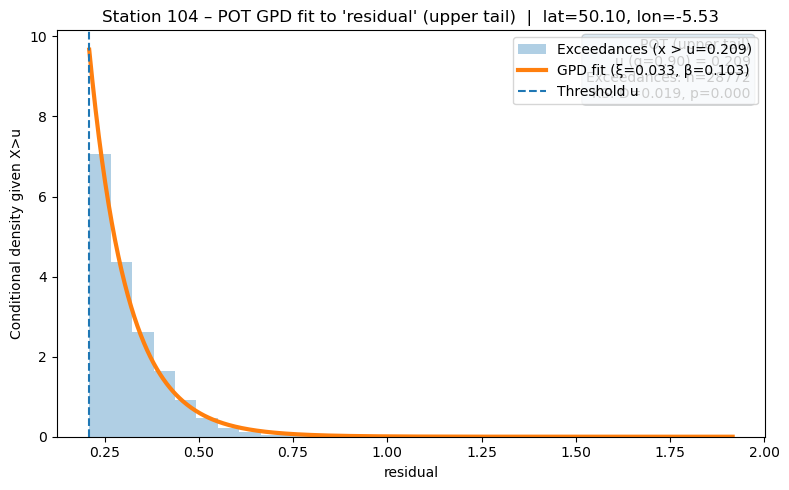

Station 104 POT GPD (upper tail):
  Threshold u (q=0.90): 0.209408
  Exceedances: n=28772/287720 (10.0%)
  GPD params: shape ξ=0.032563, scale β=0.103426 (loc fixed at 0)
  KS test: D=0.019273, p=0.000000
------------------------------------------------------------


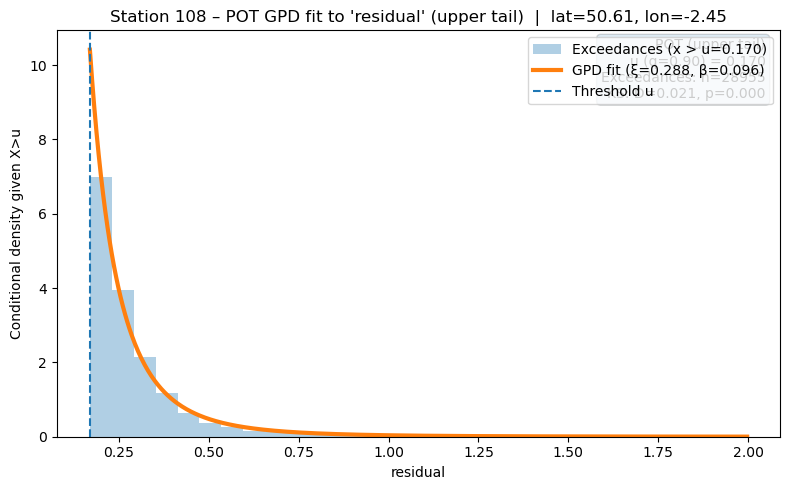

Station 108 POT GPD (upper tail):
  Threshold u (q=0.90): 0.169577
  Exceedances: n=28955/289549 (10.0%)
  GPD params: shape ξ=0.288195, scale β=0.096022 (loc fixed at 0)
  KS test: D=0.021148, p=0.000000
------------------------------------------------------------


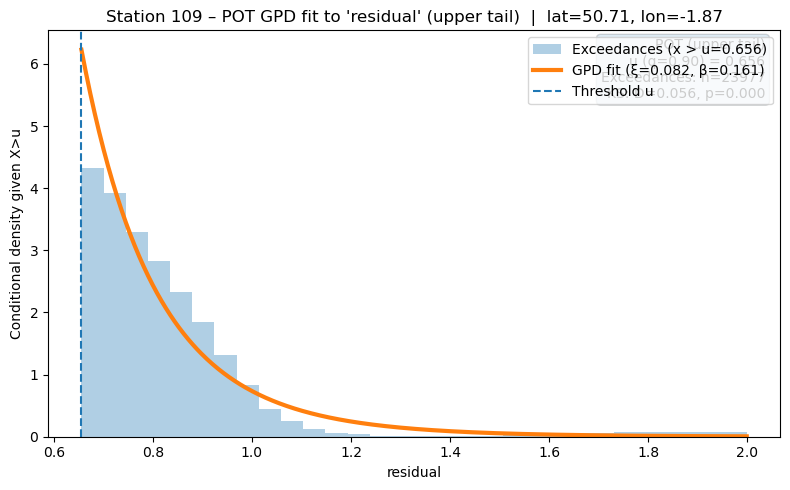

Station 109 POT GPD (upper tail):
  Threshold u (q=0.90): 0.655721
  Exceedances: n=23977/239765 (10.0%)
  GPD params: shape ξ=0.082490, scale β=0.160548 (loc fixed at 0)
  KS test: D=0.055824, p=0.000000
------------------------------------------------------------


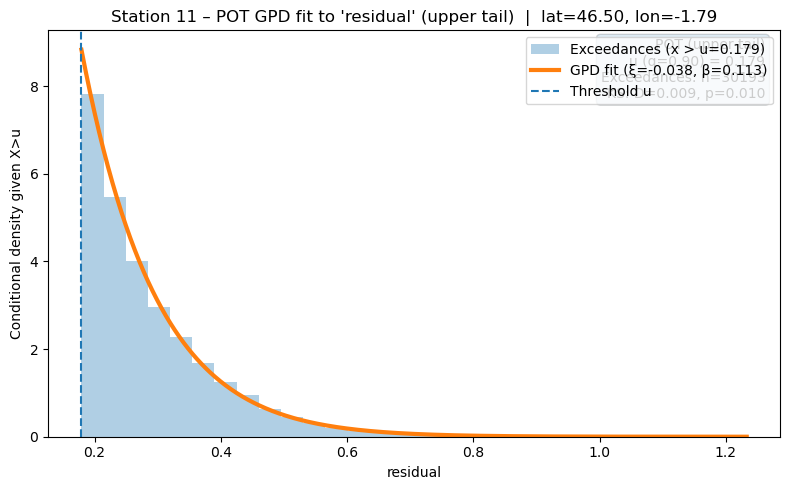

Station 11 POT GPD (upper tail):
  Threshold u (q=0.90): 0.179170
  Exceedances: n=30193/301928 (10.0%)
  GPD params: shape ξ=-0.038010, scale β=0.113199 (loc fixed at 0)
  KS test: D=0.009338, p=0.010271
------------------------------------------------------------
Skipping station 110: too few points (0).


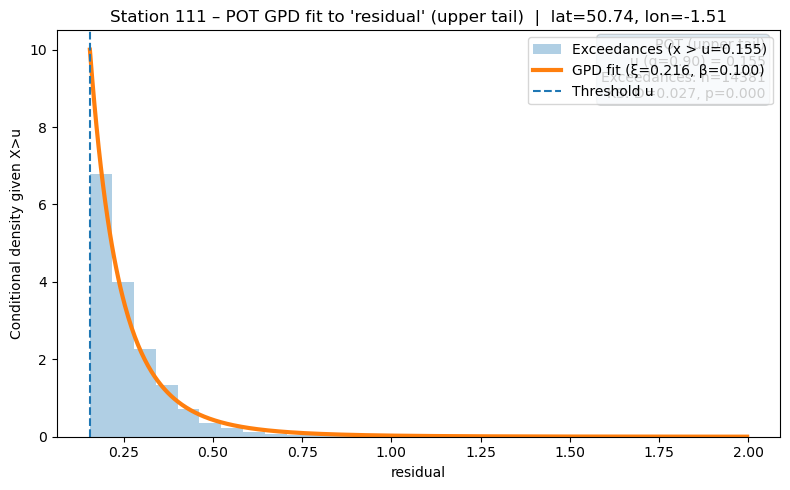

Station 111 POT GPD (upper tail):
  Threshold u (q=0.90): 0.155484
  Exceedances: n=14381/143809 (10.0%)
  GPD params: shape ξ=0.215745, scale β=0.100028 (loc fixed at 0)
  KS test: D=0.027316, p=0.000000
------------------------------------------------------------


In [ ]:
# POT (Peaks-Over-Threshold) with GPD for the first 10 stations.
# Fits GPD to upper-tail exceedances, runs K–S test, and annotates plots.

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

# --- config ---
TARGET_VAR = "residual"     # change if needed
N_STATIONS = 10
HIST_BINS = 30
MIN_EXCEED = 80             # require enough exceedances for stable fit
THRESHOLD_QUANTILE = 0.90   # high threshold for POT (e.g., 0.90–0.98 common)
USE_DESEASONED = True       # assuming residuals already; keep True

# ds = ...  # your Dataset already loaded

if TARGET_VAR not in ds.data_vars:
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

def _meta_for_station(i):
    lat = lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

stations = np.array(ds["station"].values)[:N_STATIONS]

for s in stations:
    # --- 1) get series and clean ---
    series = ds[TARGET_VAR].sel(station=s).values
    x = np.asarray(series).ravel()
    x = x[np.isfinite(x)]

    if x.size < 300:
        print(f"Skipping station {s}: too few points ({x.size}).")
        continue

    # --- 2) choose threshold u and extract exceedances y = x - u (upper tail) ---
    u = np.quantile(x, THRESHOLD_QUANTILE)
    exc_mask = x > u
    y = x[exc_mask] - u

    if y.size < MIN_EXCEED or np.all(y == 0):
        print(f"Skipping station {s}: only {y.size} exceedances above u={u:.3f} (need ≥ {MIN_EXCEED}).")
        continue

    # --- 3) fit GPD on exceedances (fix loc=0 so support starts at 0) ---
    # genpareto.fit returns (shape, loc, scale). We set loc=0.
    c, loc, scale = st.genpareto.fit(y, floc=0.0)

    # --- 4) K–S test on exceedances (y) ---
    D_gpd, p_gpd = st.kstest(y, 'genpareto', args=(c, 0.0, scale))

    # --- 5) plotting ---
    # We'll plot: histogram of exceedances (conditional on X>u) + fitted GPD pdf on x>=u.
    xs_tail = np.linspace(u, x.max(), 600)
    # pdf of (X | X>u) under GPD is the pdf of Y evaluated at (x-u)
    gpd_pdf_tail = st.genpareto.pdf(xs_tail - u, c, 0.0, scale)

    plt.figure(figsize=(8, 5))

    # Histogram of exceedances only, normalized as a density (conditional on X>u)
    plt.hist(x[exc_mask], bins=HIST_BINS, density=True, alpha=0.35, label=f"Exceedances (x > u={u:.3f})")

    # Overlay fitted conditional GPD pdf
    plt.plot(xs_tail, gpd_pdf_tail, linewidth=3, label=f"GPD fit (ξ={c:.3f}, β={scale:.3f})")

    # Mark threshold
    plt.axvline(u, linestyle="--", linewidth=1.5, label="Threshold u")

    # KS annotation
    ks_text = (f"POT (upper tail)\n"
               f"u (q={THRESHOLD_QUANTILE:.2f}) = {u:.3f}\n"
               f"Exceedances: n={y.size}\n"
               f"KS: D={D_gpd:.3f}, p={p_gpd:.3f}")
    ax = plt.gca()
    ax.text(0.98, 0.98, ks_text,
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', alpha=0.15))

    # Titles/labels
    lat, lon = _meta_for_station(s)
    meta = f"  |  lat={lat:.2f}, lon={lon:.2f}" if (lat is not None and lon is not None) else ""
    plt.title(f"Station {int(s)} – POT GPD fit to '{TARGET_VAR}' (upper tail){meta}")
    plt.xlabel(TARGET_VAR)
    plt.ylabel("Conditional density given X>u")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Console output
    print(f"Station {int(s)} POT GPD (upper tail):")
    print(f"  Threshold u (q={THRESHOLD_QUANTILE:.2f}): {u:.6f}")
    print(f"  Exceedances: n={y.size}/{x.size} ({100.0*y.size/x.size:.1f}%)")
    print(f"  GPD params: shape ξ={c:.6f}, scale β={scale:.6f} (loc fixed at 0)")
    print(f"  KS test: D={D_gpd:.6f}, p={p_gpd:.6f}")
    print("-" * 60)
